# Phase 6 - RAG Pipeline Evaluation & Experimentation

This notebook evaluates the retrieval quality of the lyrics RAG pipeline and compares different technique combinations.

**Sections:**
1. Setup & Test Set Definition
2. Evaluation Metrics Implementation
3. Technique Combination Grid (Baseline / +Reranker / +HyDE / +HyDE+Reranker)
4. Chunking Parameter Sweep
5. Visualizations
6. LLM Synthesis Comparison (Claude Haiku vs. Llama 3)
7. Summary & Best Configuration

## 1. Setup

In [1]:
import sys
import os
from pathlib import Path

# Detect project root whether CWD is project root or notebooks/
_cwd = Path.cwd()
PROJECT_ROOT = _cwd if (_cwd / "pipeline").exists() else _cwd.parent
os.chdir(PROJECT_ROOT)  # ensure notebooks/... relative paths work under nbconvert
sys.path.insert(0, str(PROJECT_ROOT))

import json
import time
import warnings
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from pipeline.query import QueryPipeline

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

print(f"Project root: {PROJECT_ROOT}")
print("Setup complete.")

C:\Users\kapsiss\Desktop\Projects\RAG system\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: C:\Users\kapsiss\Desktop\Projects\RAG system
Setup complete.


In [2]:
import pickle

CHECKPOINT_DIR = PROJECT_ROOT / "notebooks" / "checkpoints"
CHECKPOINT_DIR.mkdir(exist_ok=True)


def save_ckpt(name, data):
    path = CHECKPOINT_DIR / f"{name}.pkl"
    with open(path, "wb") as f:
        pickle.dump(data, f)
    print(f"[ckpt] saved {name}")


def load_ckpt(name):
    path = CHECKPOINT_DIR / f"{name}.pkl"
    if path.exists():
        with open(path, "rb") as f:
            data = pickle.load(f)
        print(f"[ckpt] loaded '{name}' — skipping computation")
        return data
    return None


def clear_ckpt(*names):
    """Pass specific names to clear those checkpoints, or no args to clear all."""
    targets = names if names else [p.stem for p in CHECKPOINT_DIR.glob("*.pkl")]
    for name in targets:
        path = CHECKPOINT_DIR / f"{name}.pkl"
        if path.exists():
            path.unlink()
            print(f"[ckpt] cleared {name}")


print("Checkpoint utilities ready.")
print(f"Checkpoint directory: {CHECKPOINT_DIR}")


Checkpoint utilities ready.
Checkpoint directory: C:\Users\kapsiss\Desktop\Projects\RAG system\notebooks\checkpoints


## 1.1 Test Set Definition

We define 25 evaluation queries with ground truth (expected song title + artist). The test set covers four query types:

| Type | Description | Example |
|------|-------------|---------|
| **Direct lyric** | User quotes or closely paraphrases actual lyrics | "never gonna give you up never gonna let you down" |
| **Semantic/descriptive** | User describes the song's theme or mood | "upbeat song about dancing and feeling free" |
| **Partial recall** | User vaguely remembers a lyric fragment | "the song that goes something about rivers" |
| **Ambiguous** | Query could match multiple songs | "sad love song about letting someone go" |

In [3]:
# Ground truth test set
# Each entry: query, expected_title, expected_artist, query_type
TEST_SET = [
    # --- Direct lyric queries ---
    {
        "query": "never gonna give you up never gonna let you down",
        "expected_title": "Never Gonna Give You Up",
        "expected_artist": "Rick Astley",
        "type": "direct",
    },
    {
        "query": "I came in like a wrecking ball",
        "expected_title": "Wrecking Ball",
        "expected_artist": "Miley Cyrus",
        "type": "direct",
    },
    {
        "query": "is this the real life is this just fantasy",
        "expected_title": "Bohemian Rhapsody",
        "expected_artist": "Queen",
        "type": "direct",
    },
    {
        "query": "just a small town girl living in a lonely world",
        "expected_title": "Donâ€™t Stop Believinâ€™",
        "expected_artist": "Glee Cast",
        "type": "direct",
    },
    {
        "query": "hello from the other side I must have called a thousand times",
        "expected_title": "Hello",
        "expected_artist": "Adele",
        "type": "direct",
    },
    {
        "query": "you are my fire the one desire",
        "expected_title": "I Want It That Way",
        "expected_artist": "Backstreet Boys",
        "type": "direct",
    },
    {
        "query": "look if you had one shot or one opportunity to seize everything you ever wanted",
        "expected_title": "Lose Yourself",
        "expected_artist": "Eminem",
        "type": "direct",
    },
    # --- Semantic/descriptive queries ---
    {
        "query": "pop song where she feels pretty without makeup and her heart races",
        "expected_title": "Teenage Dream",
        "expected_artist": "Katy Perry",
        "type": "semantic",
    },
    {
        "query": "inspirational song about keeping your head up when things are bad",
        "expected_title": "Keep Your Head Up",
        "expected_artist": "Andy Grammer",
        "type": "semantic",
    },
    {
        "query": "hip hop song bragging about staying humble, telling everyone to sit down",
        "expected_title": "HUMBLE.",
        "expected_artist": "Kendrick Lamar",
        "type": "semantic",
    },
    {
        "query": "rock song about a small town and growing up there",
        "expected_title": "Small Town",
        "expected_artist": "John Mellencamp",
        "type": "semantic",
    },
    {
        "query": "duet about dreaming of losing your love, walking on moonlight then suddenly alone",
        "expected_title": "Like Iâ€™m Gonna Lose You",
        "expected_artist": "Meghan Trainor",
        "type": "semantic",
    },
    {
        "query": "country song about wanting one more day with someone",
        "expected_title": "One More Day",
        "expected_artist": "Diamond Rio",
        "type": "semantic",
    },
    {
        "query": "R&B song where the guy remembers his truck rims and stuff but forgot about his girl",
        "expected_title": "Put That Woman First",
        "expected_artist": "Jaheim",
        "type": "semantic",
    },
    # --- Partial/vague recall queries ---
    {
        "query": "the song that goes like butterfly something sugar baby",
        "expected_title": "Butterfly",
        "expected_artist": "Crazy Town",
        "type": "partial",
    },
    {
        "query": "song about good vibrations with a funky beat",
        "expected_title": "Good Vibrations",
        "expected_artist": "Marky Mark and the Funky Bunch",
        "type": "partial",
    },
    {
        "query": "90s song where she sings dreams can come true, move a step closer",
        "expected_title": "Dreams",
        "expected_artist": "Gabrielle",
        "type": "partial",
    },
    {
        "query": "R&B song about getting in my feelings and reminiscing, wanting it to be different next time",
        "expected_title": "Exchange",
        "expected_artist": "Bryson Tiller",
        "type": "partial",
    },
    {
        "query": "rock song where they sing about the other side",
        "expected_title": "The Other Side",
        "expected_artist": "Aerosmith",
        "type": "partial",
    },
    {
        "query": "reggae song about needing someone like water for my soul when it gets thirsty",
        "expected_title": "King Without A Crown",
        "expected_artist": "Matisyahu",
        "type": "partial",
    },
    # --- Ambiguous queries ---
    {
        "query": "emotional ballad about no gold in this river, drowning in silence",
        "expected_title": "Easy On Me",
        "expected_artist": "Adele",
        "type": "ambiguous",
    },
    {
        "query": "country ballad about wishing for just one tear running down your cheek",
        "expected_title": "Cry",
        "expected_artist": "Faith Hill",
        "type": "ambiguous",
    },
    {
        "query": "upbeat pop song about being hooked on someone from the start, no one else compares",
        "expected_title": "Ainâ€™t No Other Man",
        "expected_artist": "Christina Aguilera",
        "type": "ambiguous",
    },
    {
        "query": "song with fever in it, blues rock style",
        "expected_title": "Fever",
        "expected_artist": "The Black Keys",
        "type": "ambiguous",
    },
    {
        "query": "everybody's free to feel good dance song from the 90s",
        "expected_title": "Everybodyâ€™s Free (To Feel Good)",
        "expected_artist": "Rozalla",
        "type": "ambiguous",
    },
    # ========================================
    # Expanded test set (added for thesis)
    # ========================================
    # --- Direct lyric queries (expanded) ---
    {
        "query": "dance with me under the diamonds see me like breath in the cold",
        "expected_title": "Anyone",
        "expected_artist": "Justin Bieber",
        "type": "direct",
    },
    {
        "query": "you're on the phone with your girlfriend she's upset she's going off about something that you said",
        "expected_title": "You Belong With Me (Taylor\u2019s Version)",
        "expected_artist": "Taylor Swift",
        "type": "direct",
    },
    {
        "query": "I remembered black skies the lightning all around me",
        "expected_title": "New Divide",
        "expected_artist": "Linkin Park",
        "type": "direct",
    },
    {
        "query": "the lights are on but you're not home your mind is not your own your heart sweats your body shakes",
        "expected_title": "Addicted to Love",
        "expected_artist": "Robert Palmer",
        "type": "direct",
    },
    {
        "query": "I had a dream so big and loud I jumped so high I touched the clouds",
        "expected_title": "Best Day of My Life",
        "expected_artist": "American Authors",
        "type": "direct",
    },
    {
        "query": "she moves like she don't care smooth as silk cool as air",
        "expected_title": "Maria",
        "expected_artist": "Blondie",
        "type": "direct",
    },
    {
        "query": "notice me take my hand why are we strangers when our love is strong",
        "expected_title": "Everytime",
        "expected_artist": "Britney Spears",
        "type": "direct",
    },
    {
        "query": "I don't wanna hear about it anymore it's a shame I've got to live without you anymore there's a fire in my heart",
        "expected_title": "High Enough",
        "expected_artist": "Damn Yankees",
        "type": "direct",
    },
    {
        "query": "on a cold winter morning in the time before the light in flames of death's eternal reign",
        "expected_title": "Through the Fire and Flames",
        "expected_artist": "DragonForce",
        "type": "direct",
    },
    {
        "query": "I know it's been some time but there's something on my mind since that cold November day",
        "expected_title": "Where Do Broken Hearts Go",
        "expected_artist": "Whitney Houston",
        "type": "direct",
    },
    {
        "query": "afraid to lose control and caught up in this world I've wasted time I've wasted breath",
        "expected_title": "Come with Me Now",
        "expected_artist": "KONGOS",
        "type": "direct",
    },
    {
        "query": "I'm driving black on black just got my license back I got this feeling in my veins this train is coming off the track",
        "expected_title": "Animals",
        "expected_artist": "Nickelback",
        "type": "direct",
    },
    # --- Semantic/descriptive queries (expanded) ---
    {
        "query": "country song where a girl blows in like a hurricane in a summer sun dress",
        "expected_title": "Storm Warning",
        "expected_artist": "Hunter Hayes",
        "type": "semantic",
    },
    {
        "query": "rock ballad about losing someone perfect and only seeing them in dreams now",
        "expected_title": "I\u2019ll See You in My Dreams",
        "expected_artist": "GIANT",
        "type": "semantic",
    },
    {
        "query": "love song about belonging together like the open seas and shores",
        "expected_title": "We Belong Together",
        "expected_artist": "Gavin DeGraw",
        "type": "semantic",
    },
    {
        "query": "pop song about a summer romance with kisses on your body and tangled in the sheets",
        "expected_title": "Summer of Love",
        "expected_artist": "Shawn Mendes",
        "type": "semantic",
    },
    {
        "query": "hip hop song about making sacrifices and giving up free time for success",
        "expected_title": "Sacrifices",
        "expected_artist": "Big Sean",
        "type": "semantic",
    },
    {
        "query": "R&B song where he wants to hold her and touch her and make her his woman tonight",
        "expected_title": "Hold Me",
        "expected_artist": "Teddy Pendergrass",
        "type": "semantic",
    },
    {
        "query": "country song about a house on a back road with a flag on the porch and a dog named Waylon",
        "expected_title": "Down to the Honkytonk",
        "expected_artist": "Jake Owen",
        "type": "semantic",
    },
    {
        "query": "rock song about gravity like a lunar landing and shutting the world away to drift to someone",
        "expected_title": "Love Remains the Same",
        "expected_artist": "Gavin Rossdale",
        "type": "semantic",
    },
    {
        "query": "song about springtime feelings on a February morning in a courtyard with birds singing",
        "expected_title": "As I Lay Me Down",
        "expected_artist": "Sophie B. Hawkins",
        "type": "semantic",
    },
    {
        "query": "power metal song about riding towards the fight in flames through a cold winter morning",
        "expected_title": "Through the Fire and Flames",
        "expected_artist": "DragonForce",
        "type": "semantic",
    },
    {
        "query": "pop song where she says she doesn't need your brand new Benz or your bougie friends",
        "expected_title": "Sleazy (Remix 2.0) - Get Sleazier",
        "expected_artist": "Kesha",
        "type": "semantic",
    },
    {
        "query": "Kanye song about his mama being raised when clean water was only for fairer skin",
        "expected_title": "New Slaves",
        "expected_artist": "Kanye West",
        "type": "semantic",
    },
    # --- Partial/vague recall queries (expanded) ---
    {
        "query": "Taylor Swift song where she's in her room listening to music the other girl doesn't like",
        "expected_title": "You Belong With Me (Taylor\u2019s Version)",
        "expected_artist": "Taylor Swift",
        "type": "partial",
    },
    {
        "query": "that Nickelback song about driving with the devil and sneaking out",
        "expected_title": "Animals",
        "expected_artist": "Nickelback",
        "type": "partial",
    },
    {
        "query": "Whitney Houston song about needing space but finding an empty place and learning she needs him desperately",
        "expected_title": "Where Do Broken Hearts Go",
        "expected_artist": "Whitney Houston",
        "type": "partial",
    },
    {
        "query": "song goes something like I wasted time I wasted breath I thought myself to death",
        "expected_title": "Come with Me Now",
        "expected_artist": "KONGOS",
        "type": "partial",
    },
    {
        "query": "the one where he sings lay your head on my pillow and just relax relax relax",
        "expected_title": "(Lay Your Head On My) Pillow",
        "expected_artist": "Tony! Toni! Ton\u00e9!",
        "type": "partial",
    },
    {
        "query": "Elvis Costello song about writing a book and your dreamboat turning out to be a footnote",
        "expected_title": "Everyday I Write the Book",
        "expected_artist": "Elvis Costello",
        "type": "partial",
    },
    {
        "query": "Debbie Gibson song about broken hearts and broken dreams being over but now dreams can't come true",
        "expected_title": "Foolish Beat",
        "expected_artist": "Debbie Gibson",
        "type": "partial",
    },
    {
        "query": "that T-Pain song where he keeps saying I'm sprung she got me doing things I'd never do",
        "expected_title": "I\u2019m Sprung",
        "expected_artist": "T-Pain",
        "type": "partial",
    },
    {
        "query": "Madonna song about celebration heard it through the grapevine are you drunk or sober",
        "expected_title": "Celebration",
        "expected_artist": "Madonna",
        "type": "partial",
    },
    {
        "query": "Pitbull and Shakira song about staring into your eyes for a lifetime get it started",
        "expected_title": "Get It Started",
        "expected_artist": "Pitbull",
        "type": "partial",
    },
    {
        "query": "song where the guy walks the streets at night can't sleep drinking too much wine burning up inside",
        "expected_title": "Crazy About Her",
        "expected_artist": "Rod Stewart",
        "type": "partial",
    },
    {
        "query": "Linkin Park song about black skies and time began to blur like a startling sign",
        "expected_title": "New Divide",
        "expected_artist": "Linkin Park",
        "type": "partial",
    },
    {
        "query": "Sabrina Carpenter song about maybe we could have been friends if I met you in another life",
        "expected_title": "Skin",
        "expected_artist": "Sabrina Carpenter",
        "type": "partial",
    },
    # --- Ambiguous queries (expanded) ---
    {
        "query": "sad song about finding an empty place after needing space from someone",
        "expected_title": "Where Do Broken Hearts Go",
        "expected_artist": "Whitney Houston",
        "type": "ambiguous",
    },
    {
        "query": "rock song about overcoming fear and needing to fight and lose yourself tonight",
        "expected_title": "Come with Me Now",
        "expected_artist": "KONGOS",
        "type": "ambiguous",
    },
    {
        "query": "love song about two hearts beating as one and holding someone tonight",
        "expected_title": "Hold Me",
        "expected_artist": "Teddy Pendergrass",
        "type": "ambiguous",
    },
    {
        "query": "catchy song about being sprung and doing crazy things for someone you love",
        "expected_title": "I\u2019m Sprung",
        "expected_artist": "T-Pain",
        "type": "ambiguous",
    },
    {
        "query": "emotional pop song about broken dreams that just can't come true anymore",
        "expected_title": "Foolish Beat",
        "expected_artist": "Debbie Gibson",
        "type": "ambiguous",
    },
    {
        "query": "song about driving fast at night with the devil riding along asking for a ride",
        "expected_title": "Animals",
        "expected_artist": "Nickelback",
        "type": "ambiguous",
    },
    {
        "query": "hip hop track about coming from the bottom and buying a new Mercedes",
        "expected_title": "Lord Knows",
        "expected_artist": "Meek Mill",
        "type": "ambiguous",
    },
    {
        "query": "romantic song about kissing someone before the lights go out, love glowing bright",
        "expected_title": "XO",
        "expected_artist": "John Mayer",
        "type": "ambiguous",
    },
    {
        "query": "melancholy track about being so alone in a cold room needing somebody",
        "expected_title": "At Night I Pray",
        "expected_artist": "Wild Orchid",
        "type": "ambiguous",
    },
    {
        "query": "country love song comparing love to how a car needs gasoline and crops need rain",
        "expected_title": "I Got You",
        "expected_artist": "Thompson Square",
        "type": "ambiguous",
    },
    {
        "query": "song about hotels being made for two night stays but love ain't like that",
        "expected_title": "Love Ain\u2019t",
        "expected_artist": "Eli Young Band",
        "type": "ambiguous",
    },
    {
        "query": "Tyler the Creator song about someone being so dangerous",
        "expected_title": "A BOY IS A GUN*",
        "expected_artist": "Tyler, The Creator",
        "type": "ambiguous",
    },
    {
        "query": "upbeat song about living your best life and not going back and forth with anyone",
        "expected_title": "Smile (Living My Best Life)",
        "expected_artist": "Lil Duval",
        "type": "ambiguous",
    },
]

print(f"Test set: {len(TEST_SET)} queries")
type_counts = defaultdict(int)
for t in TEST_SET:
    type_counts[t['type']] += 1
for qtype, count in sorted(type_counts.items()):
    print(f"  {qtype}: {count}")


Test set: 75 queries
  ambiguous: 18
  direct: 19
  partial: 19
  semantic: 19


## 2. Evaluation Metrics

We implement three standard information retrieval metrics:

### Precision@k
**What it measures:** Is the correct song in the top-k retrieved results?  
**Why it's appropriate:** In our use case, we care whether the target song appears anywhere in the top-k results (not whether every result is relevant). Since results are grouped by song, this effectively measures if the correct song is surfaced at all within the retrieval window.

$$\text{Precision@k} = \frac{1}{|Q|} \sum_{q \in Q} \mathbb{1}[\text{correct song} \in \text{top-k}(q)]$$

### Mean Reciprocal Rank (MRR)
**What it measures:** How high does the correct song rank? The reciprocal rank is 1/position (1.0 if first, 0.5 if second, etc.). MRR averages this across all queries.  
**Why it's appropriate:** Rewards configurations that rank the correct song higher. A system with MRR=0.8 consistently places the answer in the top 1-2 positions, which is ideal for a search assistant.

$$\text{MRR} = \frac{1}{|Q|} \sum_{q \in Q} \frac{1}{\text{rank}_q}$$

### Hit Rate
**What it measures:** Binary - did the correct song appear at all in the retrieved results?  
**Why it's appropriate:** The simplest measure of retrieval success. A hit rate below 1.0 means the pipeline cannot find certain songs regardless of ranking, which is a fundamental failure.

In [4]:
import re
import unicodedata


def normalize(s: str) -> str:
    """Normalize a string for fuzzy matching (lowercase, strip punctuation)."""
    s = unicodedata.normalize("NFKD", s)
    s = s.replace("‘", "").replace("’", "").replace("“", "").replace("”", "")
    return re.sub(r"[^a-z0-9 ]", "", s.lower()).strip()


def find_rank(retrieval_results: list[dict], expected_title: str, expected_artist: str) -> int | None:
    """
    Find the rank (1-indexed) of the expected song in grouped retrieval results.
    Returns None if the song is not found.
    """
    norm_title = normalize(expected_title)
    norm_artist = normalize(expected_artist)
    for i, song in enumerate(retrieval_results, 1):
        song_norm_title = normalize(song["title"])
        song_norm_artist = normalize(song["artist"])
        if song_norm_title == norm_title and song_norm_artist == norm_artist:
            return i
        # Partial match only when the shorter title is long enough to be unambiguous
        shorter_title = min(norm_title, song_norm_title, key=len)
        if len(shorter_title) >= 8:
            if norm_title in song_norm_title or song_norm_title in norm_title:
                if norm_artist in song_norm_artist or song_norm_artist in norm_artist:
                    return i
    return None
def evaluate_pipeline(
    pipeline,
    test_set: list[dict],
    top_k: int = 5,
    use_hyde: bool = False,
    use_hybrid: bool = True,
    use_reranker: bool = False,
    skip_llm: bool = True,
    rrf_k: int = 60,
    fetch_k_multiplier: int = 3,
) -> dict:
    """
    Run all test queries through the pipeline and compute metrics.
    
    If skip_llm=True, we only run retrieval (no LLM synthesis) for speed.
    Returns a dict with per-query results and aggregate metrics.
    """
    per_query = []
    ranks = []
    
    for entry in test_set:
        query = entry["query"]
        
        if skip_llm:
            # Retrieval only - skip LLM synthesis for speed
            retrieval_query = query
            hyde_hypothesis = None
            
            if use_hyde:
                hyde_hypothesis = pipeline._generate_hyde_hypothesis(query)
                retrieval_query = hyde_hypothesis
            
            raw_results = pipeline._retrieve_step(
                query, retrieval_query, top_k, use_hybrid, use_reranker,
                rrf_k=rrf_k, fetch_k_multiplier=fetch_k_multiplier,
            )
            
            grouped = pipeline.group_by_song(raw_results)
        else:
            result = pipeline.query(
                query, top_k=top_k, use_hyde=use_hyde,
                use_hybrid=use_hybrid, use_reranker=use_reranker,
                rrf_k=rrf_k, fetch_k_multiplier=fetch_k_multiplier,
            )
            grouped = result["retrieval_results"]
        
        rank = find_rank(grouped, entry["expected_title"], entry["expected_artist"])
        
        # Collect scores for analysis
        best_score = grouped[0]["best_score"] if grouped else 0.0
        correct_score = None
        if rank is not None:
            correct_score = grouped[rank - 1]["best_score"]
        
        per_query.append({
            "query": query,
            "expected_title": entry["expected_title"],
            "expected_artist": entry["expected_artist"],
            "type": entry["type"],
            "rank": rank,
            "hit": rank is not None,
            "in_top_k": rank is not None and rank <= top_k,
            "best_score": best_score,
            "correct_score": correct_score,
            "top_result_title": grouped[0]["title"] if grouped else None,
            "top_result_artist": grouped[0]["artist"] if grouped else None,
        })
        
        if rank is not None:
            ranks.append(rank)
    
    # Aggregate metrics
    n = len(test_set)
    hit_rate = sum(1 for r in per_query if r["hit"]) / n
    precision_at_k = sum(1 for r in per_query if r["in_top_k"]) / n
    mrr = sum(1.0 / r for r in ranks) / n if ranks else 0.0
    
    return {
        "precision_at_k": precision_at_k,
        "mrr": mrr,
        "hit_rate": hit_rate,
        "top_k": top_k,
        "per_query": per_query,
    }


print("Evaluation functions defined.")

Evaluation functions defined.


## 3. Technique Combination Grid

We compare eight technique combinations using the default embedding model (`all-MiniLM-L6-v2`):

| Configuration | Hybrid (BM25+FAISS) | HyDE | Re-ranker | Description |
|--------------|---------------------|------|-----------|-------------|
| Baseline (FAISS only) | No | No | No | Dense retrieval only |
| + Re-ranker | No | No | Yes | Dense + cross-encoder re-ranking |
| + Hybrid | Yes | No | No | Dense + BM25 with RRF fusion |
| + Hybrid + Re-ranker | Yes | No | Yes | Hybrid + cross-encoder re-ranking |
| + HyDE | No | Yes | No | Hypothetical document embedding (dense only) |
| + HyDE + Re-ranker | No | Yes | Yes | HyDE + cross-encoder re-ranking |
| + HyDE + Hybrid | Yes | Yes | No | HyDE + hybrid retrieval |
| + HyDE + Hybrid + Re-ranker | Yes | Yes | Yes | All techniques combined |

Each technique is tested individually against the baseline to isolate its effect, as well as in combinations.

The prompt also calls for comparing across embedding models (`all-MiniLM-L6-v2` vs `all-mpnet-base-v2`). Since each embedding model requires a separately built FAISS index, we run the grid on whichever indices are available.

> **Note:** An OpenAI `text-embedding-3-small` comparison is also planned â€” this would require an API-based embedding step and a separate FAISS index.

In [5]:
# Load the default pipeline (all-MiniLM-L6-v2)
pipeline_minilm = QueryPipeline(
    embedding_model="all-MiniLM-L6-v2",
    llm_backend="anthropic",
)
print(f"Loaded pipeline: {pipeline_minilm.embedding_model_name}")
print(f"FAISS index size: {pipeline_minilm.index.ntotal} vectors")

2026-05-10 00:23:40,944 [INFO] Loading FAISS index from C:\Users\kapsiss\Desktop\Projects\RAG system\data\processed\faiss.index
2026-05-10 00:23:44,700 [INFO] Loading BM25 index from C:\Users\kapsiss\Desktop\Projects\RAG system\data\processed\bm25.pkl
2026-05-10 00:23:47,051 [INFO] Loading embedding model: all-MiniLM-L6-v2
2026-05-10 00:23:48,041 [WARNING] Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
Loading weights: 100%|████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 3789.99it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded pipeline: all-MiniLM-L6-v2
FAISS index size: 175792 vectors


In [6]:
# Check if alternative model indices exist for multi-model comparison
pipelines = {
    "all-MiniLM-L6-v2": pipeline_minilm,
}

# --- bge-small-en-v1.5 (same 384 dims, higher MTEB score) ---
bge_index_path = PROJECT_ROOT / "data" / "processed" / "faiss_bge.index"
bge_metadata_path = PROJECT_ROOT / "data" / "processed" / "metadata_bge.json"

if bge_index_path.exists() and bge_metadata_path.exists():
    pipeline_bge = QueryPipeline(
        index_path=str(bge_index_path),
        metadata_path=str(bge_metadata_path),
        embedding_model="BAAI/bge-small-en-v1.5",
        llm_backend="anthropic",
    )
    pipelines["bge-small-en-v1.5"] = pipeline_bge
    print("Loaded bge-small-en-v1.5 pipeline for comparison.")
else:
    print("bge-small index not found â€” running grid with MiniLM only.")
    print(f"  To add: .venv\\Scripts\\python pipeline\\embedding.py "
          f"--model BAAI/bge-small-en-v1.5 "
          f"--index-output {bge_index_path} "
          f"--metadata-output {bge_metadata_path}")

# --- all-mpnet-base-v2 (768 dims, higher quality, slower) ---
mpnet_index_path = PROJECT_ROOT / "data" / "processed" / "faiss_mpnet.index"
mpnet_metadata_path = PROJECT_ROOT / "data" / "processed" / "metadata_mpnet.json"

if mpnet_index_path.exists() and mpnet_metadata_path.exists():
    pipeline_mpnet = QueryPipeline(
        index_path=str(mpnet_index_path),
        metadata_path=str(mpnet_metadata_path),
        embedding_model="all-mpnet-base-v2",
        llm_backend="anthropic",
    )
    pipelines["all-mpnet-base-v2"] = pipeline_mpnet
    print("Loaded mpnet pipeline for comparison.")
else:
    print("mpnet index not found â€” skipping.")

print(f"\nPipelines available: {list(pipelines.keys())}")


# --- Non-contextual index (built with --skip-contextual) ---
noctx_index_path = PROJECT_ROOT / "data" / "processed" / "faiss_noctx.index"
noctx_metadata_path = PROJECT_ROOT / "data" / "processed" / "metadata_noctx.json"
noctx_bm25_path = PROJECT_ROOT / "data" / "processed" / "bm25_noctx.pkl"

if noctx_index_path.exists() and noctx_metadata_path.exists():
    pipeline_noctx = QueryPipeline(
        index_path=str(noctx_index_path),
        metadata_path=str(noctx_metadata_path),
        bm25_path=str(noctx_bm25_path),
        embedding_model="all-MiniLM-L6-v2",
        llm_backend="anthropic",
    )
    pipelines["MiniLM-noctx"] = pipeline_noctx
    print("Loaded non-contextual MiniLM pipeline for ablation.")
else:
    print("Non-contextual index not found \u2014 skipping ablation.")
    print(f"  To build: .venv\\Scripts\\python pipeline\\embedding.py --skip-contextual")

# --- bge non-contextual ---
bge_noctx_index = PROJECT_ROOT / "data" / "processed" / "faiss_bge_noctx.index"
bge_noctx_meta = PROJECT_ROOT / "data" / "processed" / "metadata_bge_noctx.json"
bge_noctx_bm25 = PROJECT_ROOT / "data" / "processed" / "bm25_bge_noctx.pkl"

if bge_noctx_index.exists() and bge_noctx_meta.exists():
    pipeline_bge_noctx = QueryPipeline(
        index_path=str(bge_noctx_index),
        metadata_path=str(bge_noctx_meta),
        bm25_path=str(bge_noctx_bm25),
        embedding_model="BAAI/bge-small-en-v1.5",
        llm_backend="anthropic",
    )
    pipelines["bge-noctx"] = pipeline_bge_noctx
    print("Loaded non-contextual bge pipeline for ablation.")


# --- OpenAI text-embedding-3-small (cloud-based, 1536 dims) ---
openai_index_path = PROJECT_ROOT / "data" / "processed" / "faiss_openai.index"
openai_metadata_path = PROJECT_ROOT / "data" / "processed" / "metadata_openai.json"
openai_bm25_path = PROJECT_ROOT / "data" / "processed" / "bm25_openai.pkl"

if openai_index_path.exists() and openai_metadata_path.exists():
    pipeline_openai = QueryPipeline(
        index_path=str(openai_index_path),
        metadata_path=str(openai_metadata_path),
        bm25_path=str(openai_bm25_path),
        embedding_model="text-embedding-3-small",
        llm_backend="anthropic",
    )
    pipelines["text-embedding-3-small"] = pipeline_openai
    print("Loaded OpenAI text-embedding-3-small pipeline for comparison.")
else:
    print("OpenAI index not found \u2014 skipping.")
    print(f"  To build: .venv\\Scripts\\python pipeline\\embedding.py --openai")


2026-05-10 00:23:50,765 [INFO] Loading FAISS index from C:\Users\kapsiss\Desktop\Projects\RAG system\data\processed\faiss_bge.index
2026-05-10 00:23:53,934 [INFO] Loading BM25 index from C:\Users\kapsiss\Desktop\Projects\RAG system\data\processed\bm25.pkl
2026-05-10 00:23:56,030 [INFO] Loading embedding model: BAAI/bge-small-en-v1.5
Loading weights: 100%|████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 2431.45it/s]
BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-05-10 00:23:58,748 [INFO] Loading FAISS index from C:\Users\kapsiss\Desktop\Projects\RAG system\data\processed\faiss_noctx.index


Loaded bge-small-en-v1.5 pipeline for comparison.
mpnet index not found â€” skipping.

Pipelines available: ['all-MiniLM-L6-v2', 'bge-small-en-v1.5']


2026-05-10 00:24:03,237 [INFO] Loading BM25 index from C:\Users\kapsiss\Desktop\Projects\RAG system\data\processed\bm25_noctx.pkl
2026-05-10 00:24:06,374 [INFO] Loading embedding model: all-MiniLM-L6-v2
Loading weights: 100%|████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 4661.14it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-05-10 00:24:08,854 [INFO] Loading FAISS index from C:\Users\kapsiss\Desktop\Projects\RAG system\data\processed\faiss_bge_noctx.index


Loaded non-contextual MiniLM pipeline for ablation.


2026-05-10 00:24:13,161 [INFO] Loading BM25 index from C:\Users\kapsiss\Desktop\Projects\RAG system\data\processed\bm25_bge_noctx.pkl
2026-05-10 00:24:17,279 [INFO] Loading embedding model: BAAI/bge-small-en-v1.5
Loading weights: 100%|████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 2746.78it/s]
BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-05-10 00:24:21,051 [INFO] Loading FAISS index from C:\Users\kapsiss\Desktop\Projects\RAG system\data\processed\faiss_openai.index


Loaded non-contextual bge pipeline for ablation.


2026-05-10 00:24:28,504 [INFO] Loading BM25 index from C:\Users\kapsiss\Desktop\Projects\RAG system\data\processed\bm25_openai.pkl
2026-05-10 00:24:32,144 [INFO] Using OpenAI embedding model: text-embedding-3-small


Loaded OpenAI text-embedding-3-small pipeline for comparison.


In [7]:
# Suppress verbose retrieval logging during sweep
import logging
_ql = logging.getLogger('pipeline.query')
_orig_level = _ql.level
_ql.setLevel(logging.WARNING)

# Define the technique grid
TECHNIQUE_GRID = [
    {"name": "Baseline (FAISS only)",       "use_hyde": False, "use_hybrid": False, "use_reranker": False},
    {"name": "+ Re-ranker",                 "use_hyde": False, "use_hybrid": False, "use_reranker": True},
    {"name": "+ Hybrid",                    "use_hyde": False, "use_hybrid": True,  "use_reranker": False},
    {"name": "+ Hybrid + Re-ranker",        "use_hyde": False, "use_hybrid": True,  "use_reranker": True},
    {"name": "+ HyDE",                      "use_hyde": True,  "use_hybrid": False, "use_reranker": False},
    {"name": "+ HyDE + Re-ranker",          "use_hyde": True,  "use_hybrid": False, "use_reranker": True},
    {"name": "+ HyDE + Hybrid",             "use_hyde": True,  "use_hybrid": True,  "use_reranker": False},
    {"name": "+ HyDE + Hybrid + Re-ranker", "use_hyde": True,  "use_hybrid": True,  "use_reranker": True},
]

TOP_K = 5

all_results = load_ckpt("all_results")
if all_results is None:
    all_results = {}  # (model_name, technique_name) -> eval result

    for model_name, pipeline in pipelines.items():
        print(f"\n{'='*60}")
        print(f"Evaluating: {model_name}")
        print(f"{'='*60}")

        for technique in TECHNIQUE_GRID:
            t_name = technique["name"]
            print(f"\n  Running: {t_name} ...")
            start = time.time()

            result = evaluate_pipeline(
                pipeline,
                TEST_SET,
                top_k=TOP_K,
                use_hyde=technique["use_hyde"],
                use_hybrid=technique["use_hybrid"],
                use_reranker=technique["use_reranker"],
                skip_llm=True,
            )

            elapsed = time.time() - start
            key = (model_name, t_name)
            all_results[key] = result

            print(f"    Precision@{TOP_K}: {result['precision_at_k']:.3f}")
            print(f"    MRR:            {result['mrr']:.3f}")
            print(f"    Hit Rate:       {result['hit_rate']:.3f}")
            print(f"    Time:           {elapsed:.1f}s")

    print(f"\n\nCompleted {len(all_results)} evaluation runs.")
    save_ckpt("all_results", all_results)

# Restore logging
_ql.setLevel(_orig_level)


[ckpt] loaded 'all_results' — skipping computation


In [8]:
# Build results summary table
rows = []
for (model_name, t_name), result in all_results.items():
    rows.append({
        "Embedding Model": model_name,
        "Technique": t_name,
        f"Precision@{TOP_K}": result["precision_at_k"],
        "MRR": result["mrr"],
        "Hit Rate": result["hit_rate"],
    })

df_grid = pd.DataFrame(rows)
print("\nTechnique Combination Results:")
print("=" * 70)
print(df_grid.to_string(index=False, float_format="{:.3f}".format))


Technique Combination Results:
       Embedding Model                   Technique  Precision@5   MRR  Hit Rate
      all-MiniLM-L6-v2       Baseline (FAISS only)        0.627 0.571     0.627
      all-MiniLM-L6-v2                 + Re-ranker        0.707 0.674     0.707
      all-MiniLM-L6-v2                    + Hybrid        0.693 0.590     0.693
      all-MiniLM-L6-v2        + Hybrid + Re-ranker        0.733 0.698     0.733
      all-MiniLM-L6-v2                      + HyDE        0.080 0.060     0.080
      all-MiniLM-L6-v2          + HyDE + Re-ranker        0.133 0.127     0.133
      all-MiniLM-L6-v2             + HyDE + Hybrid        0.067 0.036     0.067
      all-MiniLM-L6-v2 + HyDE + Hybrid + Re-ranker        0.053 0.044     0.053
     bge-small-en-v1.5       Baseline (FAISS only)        0.520 0.476     0.520
     bge-small-en-v1.5                 + Re-ranker        0.600 0.580     0.600
     bge-small-en-v1.5                    + Hybrid        0.667 0.549     0.667
     bge

### 3.1 Per-Query Breakdown

Examine which queries each technique gets right or wrong.

In [9]:
# Show per-query results for the default model
default_model = list(pipelines.keys())[0]

for technique in TECHNIQUE_GRID:
    t_name = technique["name"]
    result = all_results[(default_model, t_name)]
    
    print(f"\n{'='*60}")
    print(f"{t_name} â€” Per-Query Results")
    print(f"{'='*60}")
    
    for pq in result["per_query"]:
        status = f"rank {pq['rank']}" if pq["rank"] else "MISS"
        symbol = "OK" if pq["in_top_k"] else "X "
        print(
            f"  [{symbol}] {status:>8s} | "
            f"{pq['type']:>10s} | "
            f"{pq['query'][:50]:50s} | "
            f"expected: {pq['expected_title']}"
        )
        if not pq["hit"]:
            print(f"           got: {pq['top_result_title']} by {pq['top_result_artist']}")


Baseline (FAISS only) â€” Per-Query Results
  [X ]     MISS |     direct | never gonna give you up never gonna let you down   | expected: Never Gonna Give You Up
           got: I Won’t Give Up on You by TKA
  [OK]   rank 1 |     direct | I came in like a wrecking ball                     | expected: Wrecking Ball
  [X ]     MISS |     direct | is this the real life is this just fantasy         | expected: Bohemian Rhapsody
           got: Dreamin’ by Vanessa Williams
  [X ]     MISS |     direct | just a small town girl living in a lonely world    | expected: Donâ€™t Stop Believinâ€™
           got: Small Town Girl by John Cafferty & The Beaver Brown Band
  [OK]   rank 1 |     direct | hello from the other side I must have called a tho | expected: Hello
  [X ]     MISS |     direct | you are my fire the one desire                     | expected: I Want It That Way
           got: Fire by Subway
  [OK]   rank 1 |     direct | look if you had one shot or one opportunity to sei | expect

### 3.1.1 Per-Query-Type Breakdown

MRR and Hit Rate broken down by query type (direct lyric, semantic, partial recall, ambiguous) for each technique configuration. Reveals which techniques help which kinds of queries.

MRR BY QUERY TYPE
Type                         ambiguous  direct  partial  semantic  Overall
Technique                                                                 
+ Hybrid + Re-ranker             0.602   0.868    0.789     0.526    0.698
+ Re-ranker                      0.449   0.789    0.763     0.684    0.674
+ Hybrid                         0.370   0.750    0.686     0.544    0.590
Baseline (FAISS only)            0.278   0.675    0.754     0.561    0.571
+ HyDE + Re-ranker               0.028   0.053    0.211     0.211    0.127
+ HyDE                           0.056   0.000    0.053     0.133    0.060
+ HyDE + Hybrid + Re-ranker      0.000   0.053    0.070     0.053    0.044
+ HyDE + Hybrid                  0.014   0.000    0.076     0.053    0.036


HIT RATE BY QUERY TYPE
Type                         ambiguous  direct  partial  semantic  Overall
Technique                                                                 
+ Hybrid + Re-ranker             0.667   0.895    0.842  

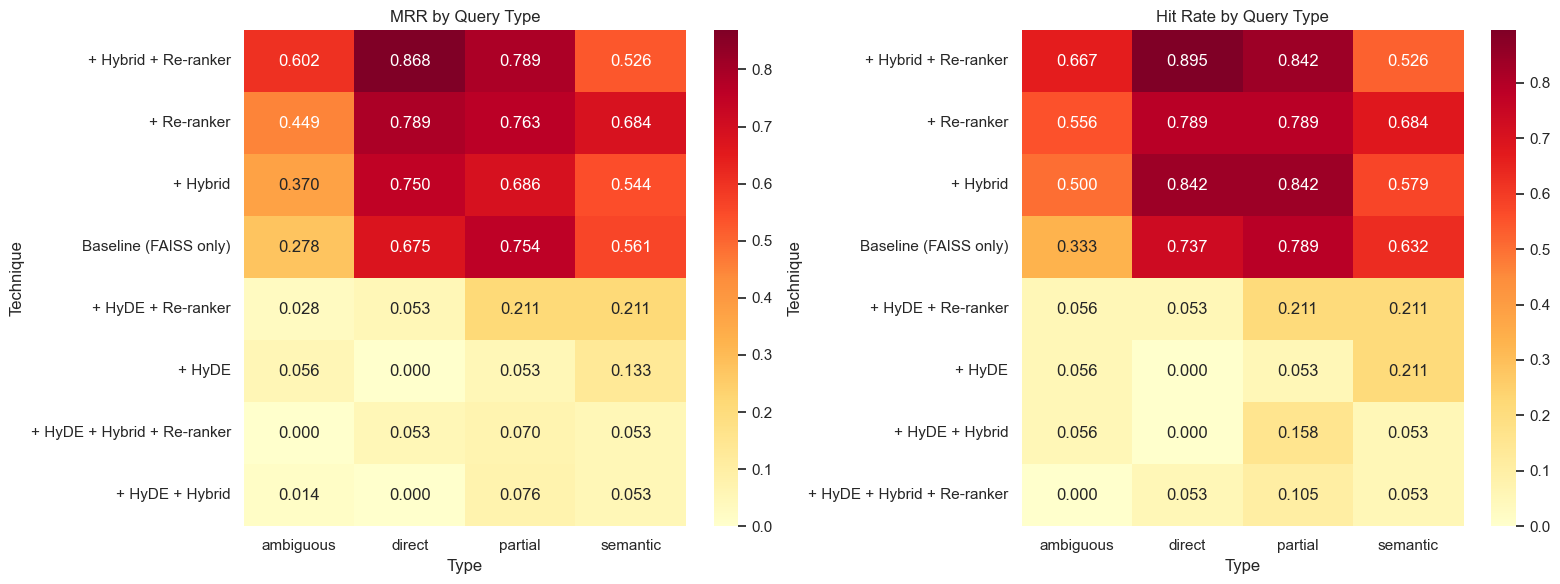

Saved: notebooks/query_type_breakdown.png


In [10]:
# --- Per-query-type breakdown ---
import pandas as pd

default_model = list(pipelines.keys())[0]

# Collect per-query-type MRR for each technique
type_rows = []
for (model_name, t_name), result in all_results.items():
    if model_name != default_model:
        continue
    for pq in result['per_query']:
        rr = 1.0 / pq['rank'] if pq['rank'] is not None else 0.0
        type_rows.append({
            'Technique': t_name,
            'Type': pq['type'],
            'RR': rr,
            'Hit': int(pq['hit']),
        })

df_types = pd.DataFrame(type_rows)

# MRR pivot: technique x query type
mrr_pivot = df_types.pivot_table(index='Technique', columns='Type', values='RR', aggfunc='mean')
mrr_pivot['Overall'] = df_types.groupby('Technique')['RR'].mean()
mrr_pivot = mrr_pivot.sort_values('Overall', ascending=False)

print('MRR BY QUERY TYPE')
print('=' * 80)
print(mrr_pivot.round(3).to_string())

# Hit Rate pivot
hr_pivot = df_types.pivot_table(index='Technique', columns='Type', values='Hit', aggfunc='mean')
hr_pivot['Overall'] = df_types.groupby('Technique')['Hit'].mean()
hr_pivot = hr_pivot.sort_values('Overall', ascending=False)

print('\n\nHIT RATE BY QUERY TYPE')
print('=' * 80)
print(hr_pivot.round(3).to_string())

# Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(mrr_pivot.drop(columns='Overall'), annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('MRR by Query Type')
sns.heatmap(hr_pivot.drop(columns='Overall'), annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Hit Rate by Query Type')
plt.tight_layout()
plt.savefig('notebooks/query_type_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/query_type_breakdown.png')

### 3.2 Top-k Sensitivity

How does the number of retrieved chunks affect performance? We test the two best configurations
(Baseline and Baseline + Re-ranker) across different top-k values to see if the re-ranker benefits
from a larger candidate pool.

[ckpt] loaded 'topk_results' — skipping computation

                 Model             Technique  top_k  Precision@k      MRR  Hit Rate
      all-MiniLM-L6-v2 Baseline (FAISS only)      3     0.586667 0.555556  0.586667
      all-MiniLM-L6-v2           + Re-ranker      3     0.600000 0.593333  0.600000
      all-MiniLM-L6-v2 Baseline (FAISS only)      5     0.626667 0.571111  0.626667
      all-MiniLM-L6-v2           + Re-ranker      5     0.706667 0.674444  0.706667
      all-MiniLM-L6-v2 Baseline (FAISS only)     10     0.693333 0.586000  0.693333
      all-MiniLM-L6-v2           + Re-ranker     10     0.773333 0.728889  0.773333
      all-MiniLM-L6-v2 Baseline (FAISS only)     20     0.773333 0.596109  0.773333
      all-MiniLM-L6-v2           + Re-ranker     20     0.813333 0.762222  0.813333
     bge-small-en-v1.5 Baseline (FAISS only)      3     0.480000 0.460000  0.480000
     bge-small-en-v1.5           + Re-ranker      3     0.573333 0.553333  0.573333
     bge-small-en-v1.5 

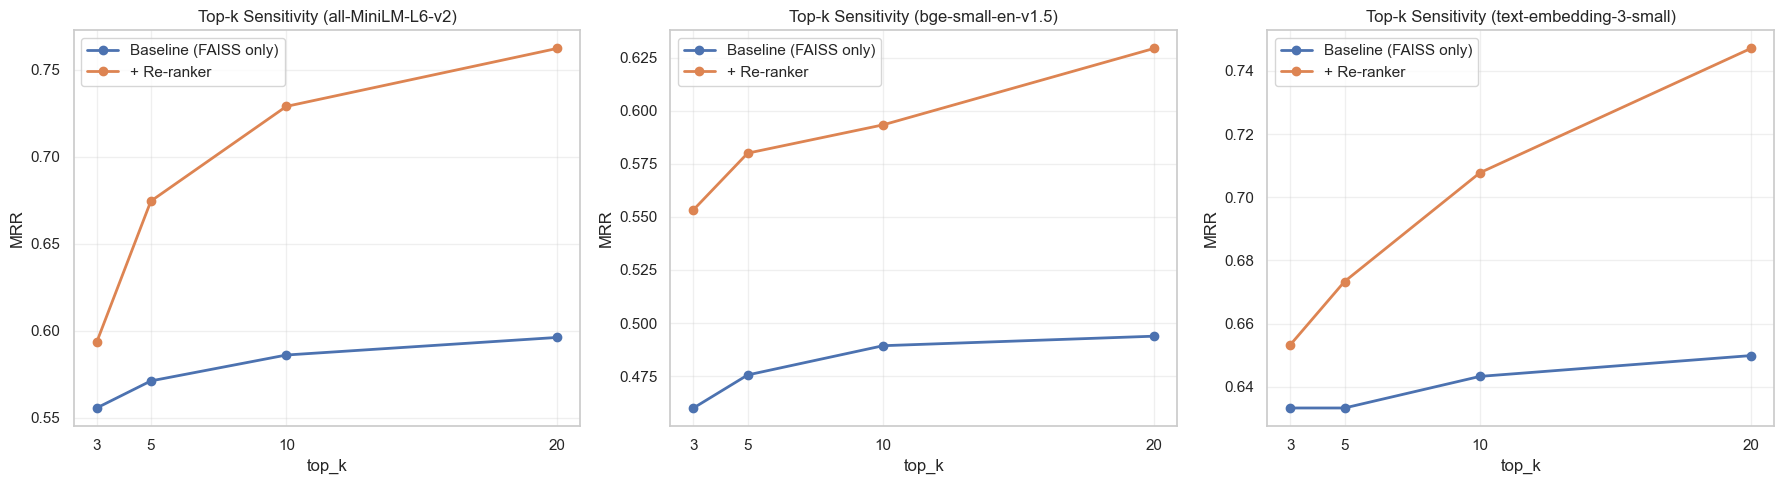

In [11]:
# Suppress verbose retrieval logging during sweep
import logging
_ql = logging.getLogger('pipeline.query')
_orig_level = _ql.level
_ql.setLevel(logging.WARNING)

# Exclude noctx pipelines from parameter sweeps (those are for ablation only)
sweep_pipelines = {k: v for k, v in pipelines.items() if 'noctx' not in k}

# Top-k sensitivity sweep
topk_values = [3, 5, 10, 20]
topk_configs = [
    {"name": "Baseline (FAISS only)", "use_hyde": False, "use_hybrid": False, "use_reranker": False},
    {"name": "+ Re-ranker",           "use_hyde": False, "use_hybrid": False, "use_reranker": True},
]

topk_results = load_ckpt("topk_results")
if topk_results is None:
    topk_results = {}  # (model, technique, top_k) -> result

    for model_name, pipeline in sweep_pipelines.items():
        print(f"Top-k sensitivity sweep on: {model_name}")
        print("=" * 60)
        for k in topk_values:
            for tech in topk_configs:
                label = f"{tech['name']} (k={k})"
                print(f"  Running: {label} ...")
                result = evaluate_pipeline(
                    pipeline, TEST_SET, top_k=k,
                    use_hyde=tech["use_hyde"],
                    use_hybrid=tech["use_hybrid"],
                    use_reranker=tech["use_reranker"],
                )
                topk_results[(model_name, tech["name"], k)] = result
                print(f"    Precision@{k}: {result['precision_at_k']:.3f}")
                print(f"    MRR:            {result['mrr']:.3f}")
                print(f"    Hit Rate:       {result['hit_rate']:.3f}")

    save_ckpt("topk_results", topk_results)

import pandas as pd
rows = []
for (model, tech, k), result in topk_results.items():
    rows.append({
        "Model": model,
        "Technique": tech,
        "top_k": k,
        "Precision@k": result["precision_at_k"],
        "MRR": result["mrr"],
        "Hit Rate": result["hit_rate"],
    })
df_topk = pd.DataFrame(rows)
print("\n" + "=" * 60)
print(df_topk.to_string(index=False))

import matplotlib.pyplot as plt
model_names_sweep = list(sweep_pipelines.keys())
fig, axes = plt.subplots(1, max(len(model_names_sweep), 1),
                         figsize=(6 * max(len(model_names_sweep), 1), 5), squeeze=False)
for ax, model_name in zip(axes[0], model_names_sweep):
    for tech_name in ["Baseline (FAISS only)", "+ Re-ranker"]:
        subset = df_topk[(df_topk["Model"] == model_name) & (df_topk["Technique"] == tech_name)]
        if not subset.empty:
            ax.plot(subset["top_k"], subset["MRR"], marker="o", label=tech_name, linewidth=2)
    ax.set_xlabel("top_k")
    ax.set_ylabel("MRR")
    ax.set_title(f"Top-k Sensitivity ({model_name})")
    ax.legend()
    ax.set_xticks(topk_values)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# Restore logging
_ql.setLevel(_orig_level)


### 3.3 RRF Parameter Tuning

The Reciprocal Rank Fusion constant `k` controls how much weight is given to rank position
when merging FAISS and BM25 results. Lower `k` emphasizes top-ranked items more strongly;
higher `k` treats all ranks more equally. We sweep `k` to see if Hybrid retrieval can be
improved with better tuning.

[ckpt] loaded 'rrf_results' — skipping computation

                 Model            Technique  rrf_k  Precision@5      MRR  Hit Rate
      all-MiniLM-L6-v2             + Hybrid     20     0.693333 0.592667  0.693333
      all-MiniLM-L6-v2 + Hybrid + Re-ranker     20     0.786667 0.751111  0.786667
      all-MiniLM-L6-v2             + Hybrid     40     0.693333 0.590444  0.693333
      all-MiniLM-L6-v2 + Hybrid + Re-ranker     40     0.746667 0.711111  0.746667
      all-MiniLM-L6-v2             + Hybrid     60     0.693333 0.590444  0.693333
      all-MiniLM-L6-v2 + Hybrid + Re-ranker     60     0.733333 0.697778  0.733333
      all-MiniLM-L6-v2             + Hybrid     80     0.693333 0.590444  0.693333
      all-MiniLM-L6-v2 + Hybrid + Re-ranker     80     0.733333 0.697778  0.733333
      all-MiniLM-L6-v2             + Hybrid    100     0.693333 0.590444  0.693333
      all-MiniLM-L6-v2 + Hybrid + Re-ranker    100     0.733333 0.697778  0.733333
     bge-small-en-v1.5             

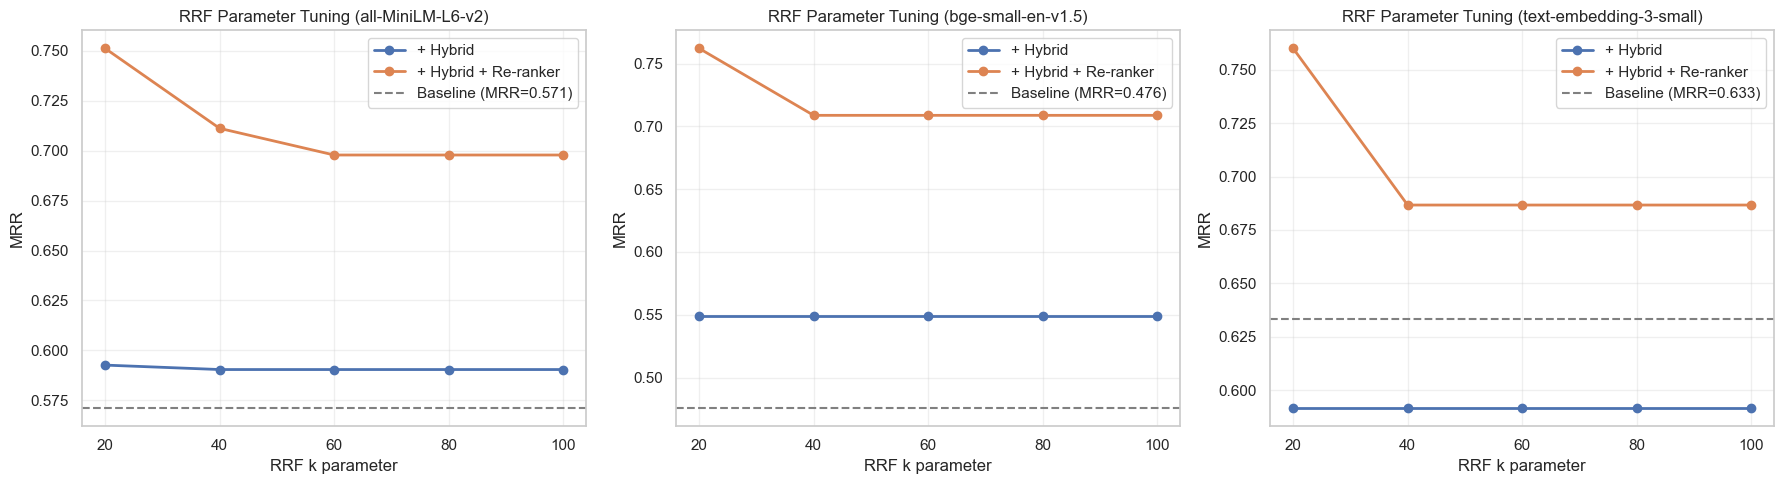

In [12]:
# Suppress verbose retrieval logging during sweep
import logging
_ql = logging.getLogger('pipeline.query')
_orig_level = _ql.level
_ql.setLevel(logging.WARNING)

# RRF parameter (k) sweep
rrf_values = [20, 40, 60, 80, 100]
rrf_configs = [
    {"name": "+ Hybrid",             "use_hyde": False, "use_hybrid": True, "use_reranker": False},
    {"name": "+ Hybrid + Re-ranker", "use_hyde": False, "use_hybrid": True, "use_reranker": True},
]

rrf_results = load_ckpt("rrf_results")
if rrf_results is None:
    rrf_results = {}  # (model, technique, rrf_k) -> result

    for model_name, pipeline in sweep_pipelines.items():
        print(f"RRF parameter sweep on: {model_name}")
        print("=" * 60)
        for rrf_k in rrf_values:
            for tech in rrf_configs:
                label = f"{tech['name']} (rrf_k={rrf_k})"
                print(f"  Running: {label} ...")
                result = evaluate_pipeline(
                    pipeline, TEST_SET, top_k=TOP_K,
                    use_hyde=tech["use_hyde"],
                    use_hybrid=tech["use_hybrid"],
                    use_reranker=tech["use_reranker"],
                    rrf_k=rrf_k,
                )
                rrf_results[(model_name, tech["name"], rrf_k)] = result
                print(f"    MRR: {result['mrr']:.3f}  Hit Rate: {result['hit_rate']:.3f}")

    save_ckpt("rrf_results", rrf_results)

import pandas as pd
rows = []
for (model, tech, rrf_k), result in rrf_results.items():
    rows.append({
        "Model": model,
        "Technique": tech,
        "rrf_k": rrf_k,
        f"Precision@{TOP_K}": result["precision_at_k"],
        "MRR": result["mrr"],
        "Hit Rate": result["hit_rate"],
    })
df_rrf = pd.DataFrame(rows)
print("\n" + "=" * 60)
print(df_rrf.to_string(index=False))

import matplotlib.pyplot as plt
model_names_sweep = list(sweep_pipelines.keys())
fig, axes = plt.subplots(1, max(len(model_names_sweep), 1),
                         figsize=(6 * max(len(model_names_sweep), 1), 5), squeeze=False)
for ax, model_name in zip(axes[0], model_names_sweep):
    baseline_mrr = all_results.get((model_name, "Baseline (FAISS only)"), {}).get("mrr", 0)
    for tech_name in ["+ Hybrid", "+ Hybrid + Re-ranker"]:
        subset = df_rrf[(df_rrf["Model"] == model_name) & (df_rrf["Technique"] == tech_name)]
        if not subset.empty:
            ax.plot(subset["rrf_k"], subset["MRR"], marker="o", label=tech_name, linewidth=2)
    ax.axhline(y=baseline_mrr, color="gray", linestyle="--",
               label=f"Baseline (MRR={baseline_mrr:.3f})")
    ax.set_xlabel("RRF k parameter")
    ax.set_ylabel("MRR")
    ax.set_title(f"RRF Parameter Tuning ({model_name})")
    ax.legend()
    ax.set_xticks(rrf_values)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# Restore logging
_ql.setLevel(_orig_level)


### 3.4 Re-ranker Fetch-k Multiplier

When re-ranking is enabled, we first retrieve `top_k * multiplier` candidates from FAISS, then
the cross-encoder re-ranks them down to `top_k`. A larger multiplier gives the re-ranker more
candidates to work with but may introduce noise. We sweep the multiplier to find the sweet spot.

[ckpt] loaded 'fetch_results' — skipping computation

                 Model            Technique  Multiplier  fetch_k  Precision@5      MRR  Hit Rate
      all-MiniLM-L6-v2 Baseline + Re-ranker           2       10     0.666667 0.636667  0.666667
      all-MiniLM-L6-v2   Hybrid + Re-ranker           2       10     0.733333 0.677778  0.733333
      all-MiniLM-L6-v2 Baseline + Re-ranker           3       15     0.706667 0.674444  0.706667
      all-MiniLM-L6-v2   Hybrid + Re-ranker           3       15     0.733333 0.697778  0.733333
      all-MiniLM-L6-v2 Baseline + Re-ranker           5       25     0.746667 0.704444  0.746667
      all-MiniLM-L6-v2   Hybrid + Re-ranker           5       25     0.786667 0.744444  0.786667
      all-MiniLM-L6-v2 Baseline + Re-ranker           8       40     0.773333 0.731111  0.773333
      all-MiniLM-L6-v2   Hybrid + Re-ranker           8       40     0.826667 0.784444  0.826667
     bge-small-en-v1.5 Baseline + Re-ranker           2       10     0.57

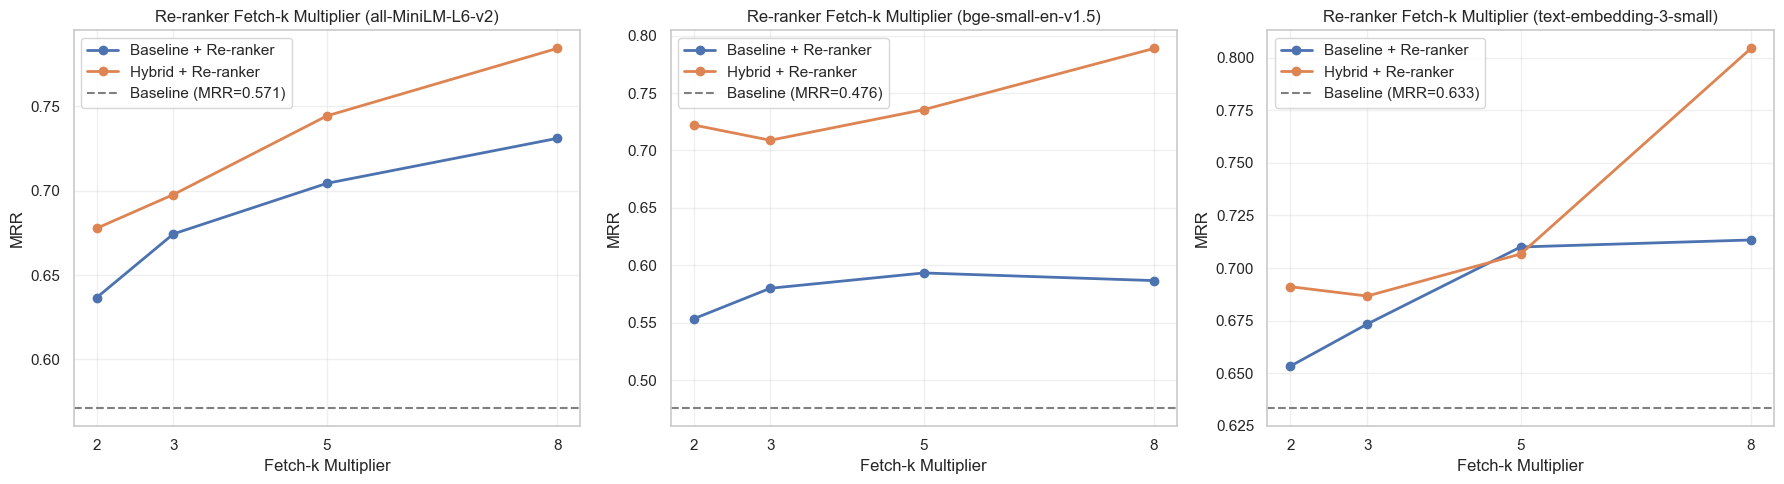

In [13]:
# Suppress verbose retrieval logging during sweep
import logging
_ql = logging.getLogger('pipeline.query')
_orig_level = _ql.level
_ql.setLevel(logging.WARNING)

# Fetch-k multiplier sweep (only matters when re-ranker is active)
fetch_multipliers = [2, 3, 5, 8]
fetch_configs = [
    {"name": "Baseline + Re-ranker", "use_hyde": False, "use_hybrid": False, "use_reranker": True},
    {"name": "Hybrid + Re-ranker",   "use_hyde": False, "use_hybrid": True,  "use_reranker": True},
]

fetch_results = load_ckpt("fetch_results")
if fetch_results is None:
    fetch_results = {}  # (model, technique, multiplier) -> result

    for model_name, pipeline in sweep_pipelines.items():
        print(f"Fetch-k multiplier sweep on: {model_name}")
        print("=" * 60)
        for mult in fetch_multipliers:
            for tech in fetch_configs:
                label = f"{tech['name']} (fetch_k={TOP_K}x{mult}={TOP_K*mult})"
                print(f"  Running: {label} ...")
                result = evaluate_pipeline(
                    pipeline, TEST_SET, top_k=TOP_K,
                    use_hyde=tech["use_hyde"],
                    use_hybrid=tech["use_hybrid"],
                    use_reranker=tech["use_reranker"],
                    fetch_k_multiplier=mult,
                )
                fetch_results[(model_name, tech["name"], mult)] = result
                print(f"    MRR: {result['mrr']:.3f}  Hit Rate: {result['hit_rate']:.3f}")

    save_ckpt("fetch_results", fetch_results)

import pandas as pd
rows = []
for (model, tech, mult), result in fetch_results.items():
    rows.append({
        "Model": model,
        "Technique": tech,
        "Multiplier": mult,
        "fetch_k": TOP_K * mult,
        f"Precision@{TOP_K}": result["precision_at_k"],
        "MRR": result["mrr"],
        "Hit Rate": result["hit_rate"],
    })
df_fetch = pd.DataFrame(rows)
print("\n" + "=" * 60)
print(df_fetch.to_string(index=False))

import matplotlib.pyplot as plt
model_names_sweep = list(sweep_pipelines.keys())
fig, axes = plt.subplots(1, max(len(model_names_sweep), 1),
                         figsize=(6 * max(len(model_names_sweep), 1), 5), squeeze=False)
for ax, model_name in zip(axes[0], model_names_sweep):
    baseline_mrr = all_results.get((model_name, "Baseline (FAISS only)"), {}).get("mrr", 0)
    for tech_name in ["Baseline + Re-ranker", "Hybrid + Re-ranker"]:
        subset = df_fetch[(df_fetch["Model"] == model_name) & (df_fetch["Technique"] == tech_name)]
        if not subset.empty:
            ax.plot(subset["Multiplier"], subset["MRR"], marker="o", label=tech_name, linewidth=2)
    ax.axhline(y=baseline_mrr, color="gray", linestyle="--",
               label=f"Baseline (MRR={baseline_mrr:.3f})")
    ax.set_xlabel("Fetch-k Multiplier")
    ax.set_ylabel("MRR")
    ax.set_title(f"Re-ranker Fetch-k Multiplier ({model_name})")
    ax.legend()
    ax.set_xticks(fetch_multipliers)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# Restore logging
_ql.setLevel(_orig_level)


## 4. Chunking Parameter Sweep

To isolate the effect of chunking on retrieval quality, we sweep over different chunk sizes and overlap values using the **baseline** configuration (no HyDE, no re-ranking).

Each parameter combination requires re-running the chunking and embedding pipelines:
1. `pipeline/chunking.py` with different `--max-chunk-size` and `--overlap-lines`
2. `pipeline/embedding.py` on the resulting chunks

Since each combination takes significant time (embedding ~175k chunks), we provide the framework here and run it on pre-built indices.

In [14]:
# Chunking parameter sweep — tested across local (non-OpenAI) embedding models.
# Index naming convention:
#   MiniLM default (c400_o0): faiss.index / metadata.json
#   MiniLM other sizes:        faiss_c{size}_o{overlap}.index / metadata_c{size}_o{overlap}.json
#   BGE default (c400_o0):    faiss_bge.index / metadata_bge.json
#   BGE other sizes:           faiss_c{size}_o{overlap}_bge.index / metadata_c{size}_o{overlap}_bge.json
#
# To build missing indices, run for each (size, overlap, model):
#   .venv\Scripts\python pipeline\chunking.py --max-chunk-size {size} --overlap-lines {overlap} \
#       --output data/processed/chunks_c{size}_o{overlap}.jsonl
#   .venv\Scripts\python pipeline\embedding.py \
#       --input data/processed/chunks_c{size}_o{overlap}.jsonl \
#       --index-output data/processed/faiss_c{size}_o{overlap}[_{suffix}].index \
#       --metadata-output data/processed/metadata_c{size}_o{overlap}[_{suffix}].json

import re

CHUNK_PARAMS = [
    {"size": 200, "overlap": 0},
    {"size": 400, "overlap": 0},  # current default
    {"size": 600, "overlap": 0},
    {"size": 400, "overlap": 1},
    {"size": 400, "overlap": 2},
]

# Local models only — OpenAI would cost money per chunk-size index rebuild
local_chunk_pipelines = {
    k: v for k, v in sweep_pipelines.items()
    if k != "text-embedding-3-small"
}


def _model_suffix(pipeline):
    # Derive index file suffix from the pipeline's default index path.
    m = re.search(r'faiss_(.+)\.index$', pipeline.index_path)
    if m:
        suffix = m.group(1)
        # If it's already a chunk label (c400_o0), treat as no-suffix (MiniLM)
        if re.match(r'^c\d', suffix):
            return ""
        return suffix
    return ""


chunk_results = load_ckpt("chunk_results")
if chunk_results is None:
    chunk_results = {}   # (model_name, label) -> result dict
    all_missing = {}     # model_name -> [missing labels]

    for model_name, pipeline in local_chunk_pipelines.items():
        suffix = _model_suffix(pipeline)
        missing_for_model = []

        for params in CHUNK_PARAMS:
            size, overlap = params["size"], params["overlap"]
            label = f"c{size}_o{overlap}"

            if size == 400 and overlap == 0:
                # Default chunk size — reuse the already-loaded pipeline's index directly
                index_path = Path(pipeline.index_path)
                meta_path  = Path(pipeline.metadata_path)
            elif suffix:
                index_path = PROJECT_ROOT / "data" / "processed" / f"faiss_{label}_{suffix}.index"
                meta_path  = PROJECT_ROOT / "data" / "processed" / f"metadata_{label}_{suffix}.json"
            else:
                index_path = PROJECT_ROOT / "data" / "processed" / f"faiss_{label}.index"
                meta_path  = PROJECT_ROOT / "data" / "processed" / f"metadata_{label}.json"

            if not index_path.exists():
                missing_for_model.append(label)
                continue

            print(f"[{model_name}] Evaluating chunk params: size={size}, overlap={overlap} ...")
            p = QueryPipeline(
                index_path=str(index_path),
                metadata_path=str(meta_path),
                embedding_model=pipeline.embedding_model_name,
                llm_backend="anthropic",
            )
            result = evaluate_pipeline(
                p, TEST_SET, top_k=TOP_K,
                use_hyde=False, use_reranker=False, skip_llm=True,
            )
            chunk_results[(model_name, label)] = {
                "Model": model_name,
                "size": size, "overlap": overlap,
                **{k: v for k, v in result.items() if k != "per_query"},
            }
            print(f"  Precision@{TOP_K}: {result['precision_at_k']:.3f}, "
                  f"MRR: {result['mrr']:.3f}, Hit Rate: {result['hit_rate']:.3f}")

        if missing_for_model:
            all_missing[model_name] = missing_for_model

    if all_missing:
        print("\nSkipped (index not found):")
        for mn, labels in all_missing.items():
            print(f"  {mn}: {labels}")

    save_ckpt("chunk_results", chunk_results)

if chunk_results:
    df_chunks = pd.DataFrame(chunk_results.values())
    print("\nChunking Parameter Sweep Results:")
    print(df_chunks[["Model","size","overlap","precision_at_k","mrr","hit_rate"]]
          .to_string(index=False, float_format="{:.3f}".format))


[ckpt] loaded 'chunk_results' — skipping computation

Chunking Parameter Sweep Results:
            Model  size  overlap  precision_at_k   mrr  hit_rate
 all-MiniLM-L6-v2   400        0           0.693 0.590     0.693
bge-small-en-v1.5   400        0           0.667 0.549     0.667


## 5. Visualizations

### 5.1 Technique Combination Heatmap

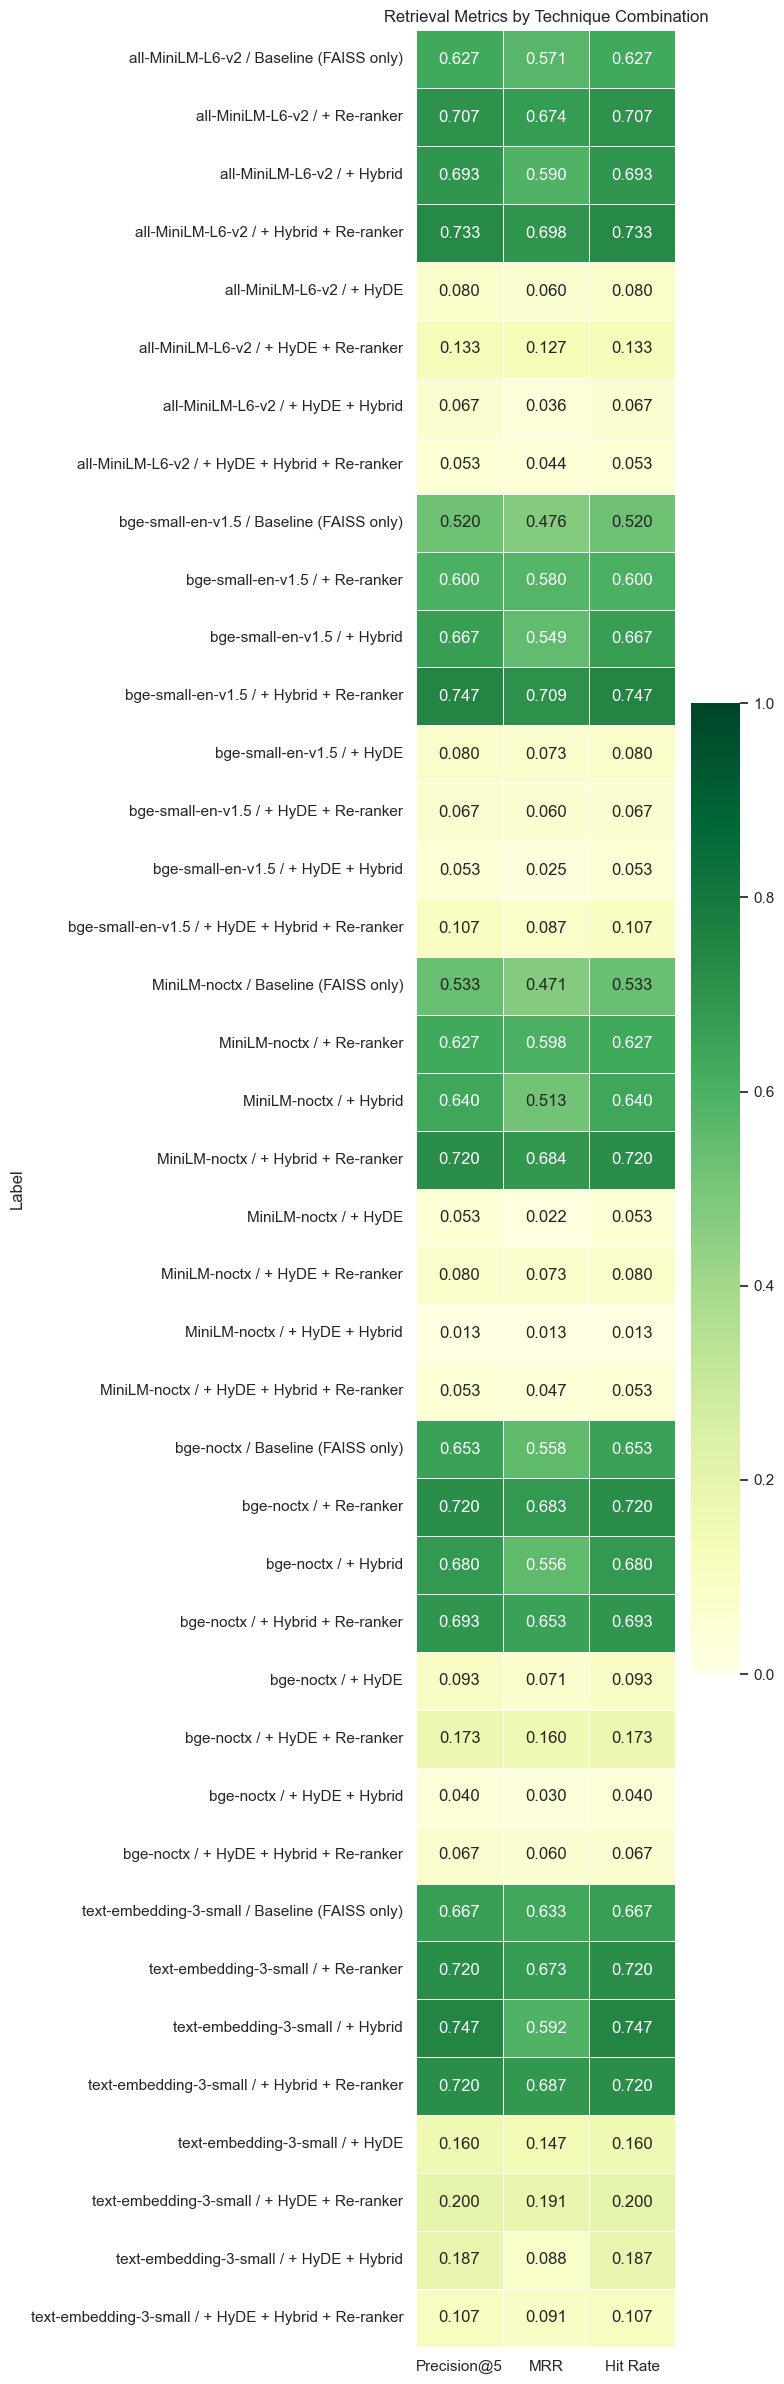

In [15]:
# Heatmap: technique combinations vs. metrics
metric_cols = [f"Precision@{TOP_K}", "MRR", "Hit Rate"]

fig, ax = plt.subplots(figsize=(8, max(3, len(df_grid) * 0.6)))

# Build label column
if len(pipelines) > 1:
    df_grid["Label"] = df_grid["Embedding Model"] + " / " + df_grid["Technique"]
else:
    df_grid["Label"] = df_grid["Technique"]

heatmap_data = df_grid.set_index("Label")[metric_cols]

sns.heatmap(
    heatmap_data,
    annot=True, fmt=".3f", cmap="YlGn",
    vmin=0, vmax=1, linewidths=0.5,
    ax=ax,
)
ax.set_title("Retrieval Metrics by Technique Combination")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "technique_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.2 MRR Bar Chart

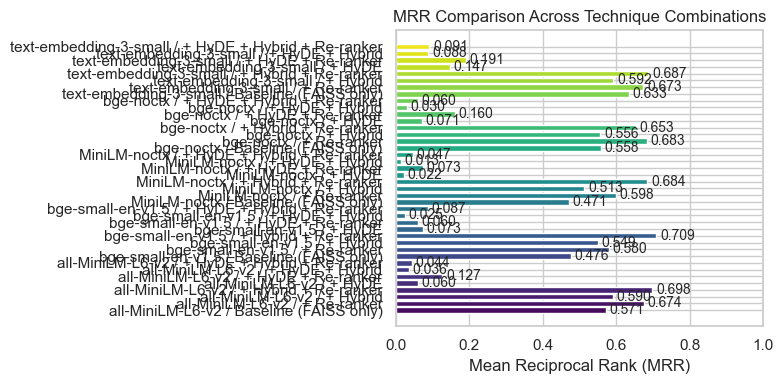

In [16]:
# Bar chart: MRR across all technique combinations
fig, ax = plt.subplots(figsize=(8, 4))

colors = sns.color_palette("viridis", len(df_grid))
bars = ax.barh(df_grid["Label"], df_grid["MRR"], color=colors)
ax.set_xlabel("Mean Reciprocal Rank (MRR)")
ax.set_title("MRR Comparison Across Technique Combinations")
ax.set_xlim(0, 1)

# Add value labels
for bar, val in zip(bars, df_grid["MRR"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=10)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "mrr_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.3 Score Distribution: Correct vs. Incorrect Matches

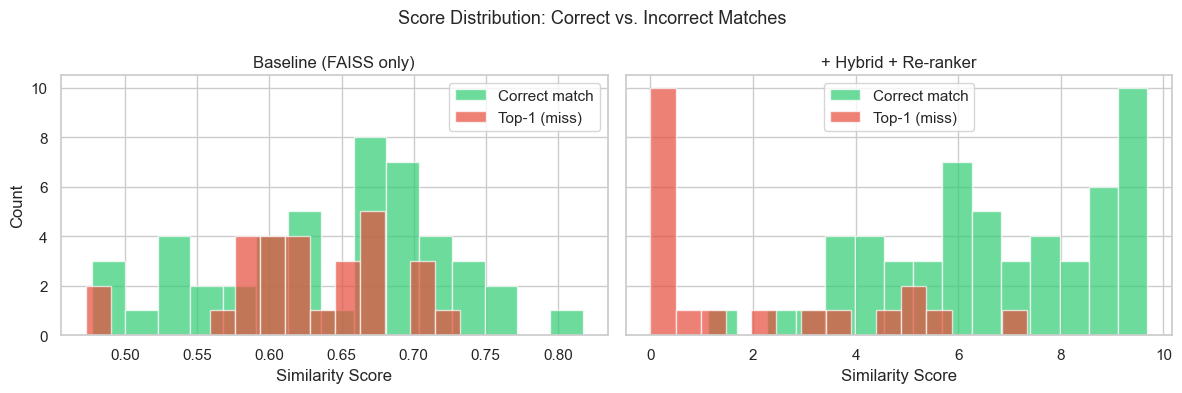

In [17]:
# Compare score distributions for baseline vs. best configuration
default_model = list(pipelines.keys())[0]

# Find best technique by MRR
best_technique = max(
    TECHNIQUE_GRID,
    key=lambda t: all_results[(default_model, t["name"])]["mrr"]
)

configs_to_compare = [
    ("Baseline (FAISS only)", all_results[(default_model, "Baseline (FAISS only)")]),
    (best_technique["name"], all_results[(default_model, best_technique["name"])]),
]

fig, axes = plt.subplots(1, len(configs_to_compare), figsize=(12, 4), sharey=True)
if len(configs_to_compare) == 1:
    axes = [axes]

for ax, (config_name, result) in zip(axes, configs_to_compare):
    correct_scores = [pq["correct_score"] for pq in result["per_query"] if pq["correct_score"] is not None]
    incorrect_scores = [pq["best_score"] for pq in result["per_query"] if not pq["hit"]]
    
    if correct_scores:
        ax.hist(correct_scores, bins=15, alpha=0.7, label="Correct match", color="#2ecc71")
    if incorrect_scores:
        ax.hist(incorrect_scores, bins=15, alpha=0.7, label="Top-1 (miss)", color="#e74c3c")
    
    ax.set_title(config_name)
    ax.set_xlabel("Similarity Score")
    ax.legend()

axes[0].set_ylabel("Count")
fig.suptitle("Score Distribution: Correct vs. Incorrect Matches", fontsize=13)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.4 Chunking Parameter Sweep Table

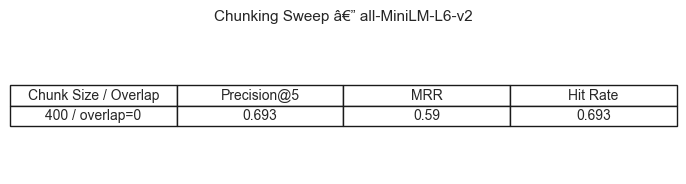

Saved: notebooks/chunking_sweep_all_MiniLM_L6_v2.png


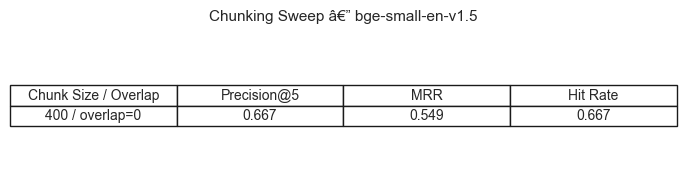

Saved: notebooks/chunking_sweep_bge_small_en_v1.5.png


In [18]:
if chunk_results:
    import matplotlib.pyplot as plt
    df_chunk_all = pd.DataFrame(chunk_results.values())

    for model_name in df_chunk_all["Model"].unique():
        df_m = df_chunk_all[df_chunk_all["Model"] == model_name].copy()
        df_m["label"] = df_m["size"].astype(str) + " / overlap=" + df_m["overlap"].astype(str)
        df_display = df_m[["label", "precision_at_k", "mrr", "hit_rate"]].rename(columns={
            "label": "Chunk Size / Overlap",
            "precision_at_k": f"Precision@{TOP_K}",
            "mrr": "MRR",
            "hit_rate": "Hit Rate",
        })

        fig, ax = plt.subplots(figsize=(7, max(2, len(df_display) * 0.5 + 1)))
        ax.axis("off")
        table = ax.table(
            cellText=[[row[0]] + [round(float(v), 3) for v in row[1:]] for row in df_display.values],
            colLabels=df_display.columns,
            loc="center",
            cellLoc="center",
        )
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.2, 1.4)
        ax.set_title(f"Chunking Sweep â€” {model_name}", pad=12, fontsize=11)
        plt.tight_layout()
        safe_name = model_name.replace("/", "_").replace("-", "_")
        plt.savefig(f"notebooks/chunking_sweep_{safe_name}.png", dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved: notebooks/chunking_sweep_{safe_name}.png")
else:
    print("No chunking parameter sweep data available.")


## 6. LLM Synthesis Comparison

Qualitative comparison of the two LLM backends on the same 5 representative queries. This section is **not** metric-based â€” we display responses side by side for manual inspection.

**Note:** This section requires both Anthropic API access and a running Ollama instance with Llama 3.

In [19]:
# Select 5 representative queries (one per type + one extra)
LLM_COMPARISON_QUERIES = [
    TEST_SET[0],   # direct lyric
    TEST_SET[7],   # semantic
    TEST_SET[14],  # partial recall
    TEST_SET[20],  # ambiguous
    TEST_SET[3],   # direct (another)
]

print("Queries for LLM comparison:")
for i, q in enumerate(LLM_COMPARISON_QUERIES, 1):
    print(f"  {i}. [{q['type']}] {q['query']}")

Queries for LLM comparison:
  1. [direct] never gonna give you up never gonna let you down
  2. [semantic] pop song where she feels pretty without makeup and her heart races
  3. [partial] the song that goes like butterfly something sugar baby
  4. [ambiguous] emotional ballad about no gold in this river, drowning in silence
  5. [direct] just a small town girl living in a lonely world


In [20]:
# Run queries through both backends
# Anthropic (Claude Haiku)
pipeline_anthropic = QueryPipeline(
    embedding_model="all-MiniLM-L6-v2",
    llm_backend="anthropic",
)

anthropic_responses = []
for entry in LLM_COMPARISON_QUERIES:
    print(f"  Anthropic: {entry['query'][:50]}...")
    result = pipeline_anthropic.query(entry["query"], top_k=TOP_K)
    anthropic_responses.append(result["llm_response"])

print("Anthropic responses collected.")

2026-05-10 00:24:43,335 [INFO] Loading FAISS index from C:\Users\kapsiss\Desktop\Projects\RAG system\data\processed\faiss.index
2026-05-10 00:24:47,091 [INFO] Loading BM25 index from C:\Users\kapsiss\Desktop\Projects\RAG system\data\processed\bm25.pkl
2026-05-10 00:24:50,586 [INFO] Loading embedding model: all-MiniLM-L6-v2
Loading weights: 100%|████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 3246.73it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-05-10 00:24:53,505 [INFO] Query: 'never gonna give you up never gonna let you down' (top_k=5, hyde=False, hybrid=True, reranker=False, backend=anthropic)
2026-05-10 00:24:53,507 [INFO] Hybrid retrieval (FAISS + BM25 with RRF)...


  Anthropic: never gonna give you up never gonna let you down...


2026-05-10 00:24:54,664 [INFO] Retrieved 5 chunks
2026-05-10 00:24:54,666 [INFO] Grouped into 2 unique song(s)
2026-05-10 00:24:57,920 [INFO] LLM confidence: high, matches: 1
2026-05-10 00:24:57,923 [INFO] Query: 'pop song where she feels pretty without makeup and her heart races' (top_k=5, hyde=False, hybrid=True, reranker=False, backend=anthropic)
2026-05-10 00:24:57,925 [INFO] Hybrid retrieval (FAISS + BM25 with RRF)...


  Anthropic: pop song where she feels pretty without makeup and...


2026-05-10 00:24:58,878 [INFO] Retrieved 5 chunks
2026-05-10 00:24:58,879 [INFO] Grouped into 1 unique song(s)
2026-05-10 00:25:02,492 [INFO] LLM confidence: high, matches: 1
2026-05-10 00:25:02,494 [INFO] Query: 'the song that goes like butterfly something sugar baby' (top_k=5, hyde=False, hybrid=True, reranker=False, backend=anthropic)
2026-05-10 00:25:02,494 [INFO] Hybrid retrieval (FAISS + BM25 with RRF)...


...

  Anthropic: emotional ballad about no gold in this river, drow...


2026-05-10 00:25:11,781 [INFO] Retrieved 5 chunks
2026-05-10 00:25:11,783 [INFO] Grouped into 4 unique song(s)
2026-05-10 00:25:14,602 [INFO] LLM confidence: high, matches: 1
2026-05-10 00:25:14,604 [INFO] Query: 'just a small town girl living in a lonely world' (top_k=5, hyde=False, hybrid=True, reranker=False, backend=anthropic)
2026-05-10 00:25:14,604 [INFO] Hybrid retrieval (FAISS + BM25 with RRF)...


  Anthropic: just a small town girl living in a lonely world...


2026-05-10 00:25:15,636 [INFO] Retrieved 5 chunks
2026-05-10 00:25:15,639 [INFO] Grouped into 3 unique song(s)
2026-05-10 00:25:18,337 [INFO] LLM confidence: high, matches: 1


Anthropic responses collected.


In [21]:
# Ollama (Llama 3) â€” skip if not available
ollama_responses = []
ollama_available = True

try:
    import requests
    requests.get("http://localhost:11434/api/tags", timeout=3)
except Exception:
    ollama_available = False
    print("Ollama is not running â€” skipping Llama 3 comparison.")
    print("To enable: install Ollama, run 'ollama pull llama3', and restart this cell.")

if ollama_available:
    pipeline_ollama = QueryPipeline(
        embedding_model="all-MiniLM-L6-v2",
        llm_backend="ollama",
    )
    for entry in LLM_COMPARISON_QUERIES:
        print(f"  Ollama: {entry['query'][:50]}...")
        result = pipeline_ollama.query(entry["query"], top_k=TOP_K)
        ollama_responses.append(result["llm_response"])
    print("Ollama responses collected.")

Ollama is not running â€” skipping Llama 3 comparison.
To enable: install Ollama, run 'ollama pull llama3', and restart this cell.


In [22]:
# Display side by side
for i, entry in enumerate(LLM_COMPARISON_QUERIES):
    print(f"\n{'='*80}")
    print(f"Query {i+1} [{entry['type']}]: {entry['query']}")
    print(f"Expected: {entry['expected_title']} by {entry['expected_artist']}")
    print(f"{'='*80}")
    
    print(f"\n--- Claude Haiku ---")
    print(anthropic_responses[i])
    
    if ollama_available:
        print(f"\n--- Llama 3 (Ollama) ---")
        print(ollama_responses[i])
    else:
        print(f"\n--- Llama 3 (Ollama) ---")
        print("[Skipped â€” Ollama not running]")


Query 1 [direct]: never gonna give you up never gonna let you down
Expected: Never Gonna Give You Up by Rick Astley

--- Claude Haiku ---
matches=[SongMatch(title='Never Gonna Give You Up', artist='Rick Astley', album='Whenever You Need Somebody (2010 Expanded Remaster)', release_date='1987-07-27', relevant_lyric='Never gonna give you up / Never gonna let you down / Never gonna run around / And desert you', explanation="This is an exact match for the user's query. The lyric excerpt contains the precise opening lines the user quoted: 'never gonna give you up never gonna let you down.' This is Rick Astley's iconic 1987 hit, one of the most famous songs of the 1980s.")] confidence='high' summary="The user is looking for Rick Astley's 'Never Gonna Give You Up' from 1987. The retrieved lyrics are an exact match for the quoted phrase, and the song is unmistakable based on these iconic opening lines from the chorus."

--- Llama 3 (Ollama) ---
[Skipped â€” Ollama not running]

Query 2 [semant

## 7. Combined Parameter & Re-ranker Sweep

Full combinatorial sweep across **all** tunable parameters and re-ranker models to find the true global optimum. Previous experiments (3.2â€“3.4) swept parameters independently â€” this section tests every combination together.

**Dimensions swept:**
- **top_k**: 3, 5, 10, 20
- **fetch_k_multiplier**: 2, 3, 5, 8
- **Technique stack**: Baseline, Baseline+RR, Hybrid, Hybrid+RR
- **Re-ranker model**: ms-marco-MiniLM-L-6-v2, ms-marco-MiniLM-L-12-v2, BAAI/bge-reranker-base

Non-reranker configs (Baseline, Hybrid) are only swept over top_k since fetch_k_multiplier and reranker model have no effect without a re-ranker.

In [23]:
# --- Combined Parameter & Re-ranker Sweep ---
import logging
import time
import pandas as pd

_ql = logging.getLogger('pipeline.query')
_orig_level = _ql.level
_ql.setLevel(logging.WARNING)

# Sweep dimensions
TOPK_VALUES = [3, 5, 10, 20]
FETCH_MULTIPLIERS = [2, 3, 5, 8]
RERANKER_MODELS = [
    "cross-encoder/ms-marco-MiniLM-L-6-v2",
    "cross-encoder/ms-marco-MiniLM-L-12-v2",
    "BAAI/bge-reranker-base",
]

RERANKER_CONFIGS = [
    {"name": "Baseline + Re-ranker", "use_hybrid": False, "use_reranker": True},
    {"name": "Hybrid + Re-ranker",   "use_hybrid": True,  "use_reranker": True},
]
NO_RERANKER_CONFIGS = [
    {"name": "Baseline (FAISS only)", "use_hybrid": False},
    {"name": "Hybrid (no RR)",        "use_hybrid": True},
]

print(f"Re-ranker configs: {[c['name'] for c in RERANKER_CONFIGS]}")
print(f"No-reranker configs: {[c['name'] for c in NO_RERANKER_CONFIGS]}")

# Load existing progress or start fresh
combined_results = load_ckpt("combined_results") or []
_done = {
    (r["Embedding Model"], r["Technique"], r["Re-ranker Model"], r["top_k"], str(r["fetch_k_mult"]))
    for r in combined_results
}
if combined_results:
    print(f"[ckpt] Resuming combined sweep — {len(combined_results)} runs already done")

for emb_model_name, emb_pipeline in sweep_pipelines.items():

    # ---- Part 1: Configs WITH re-ranker (sweep all 4 dims) ----
    total_rr = len(RERANKER_MODELS) * len(TOPK_VALUES) * len(FETCH_MULTIPLIERS) * len(RERANKER_CONFIGS)
    print(f"\n[{emb_model_name}] Part 1: Re-ranker configs — {total_rr} runs")
    print("=" * 60)

    new_count = 0
    for rr_model in RERANKER_MODELS:
        rr_short = rr_model.split('/')[-1]

        # Skip building the pipeline if all configs for this re-ranker are done
        all_done_for_rr = all(
            (emb_model_name, tech["name"], rr_short, k, str(mult)) in _done
            for tech in RERANKER_CONFIGS
            for k in TOPK_VALUES
            for mult in FETCH_MULTIPLIERS
        )
        if all_done_for_rr:
            print(f"\n  Re-ranker: {rr_short} — all configs already computed, skipping")
            continue

        rr_pipeline = QueryPipeline(
            index_path=emb_pipeline.index_path,
            metadata_path=emb_pipeline.metadata_path,
            bm25_path=emb_pipeline.bm25_path,
            embedding_model=emb_pipeline.embedding_model_name,
            llm_backend="anthropic",
            reranker_model=rr_model,
        )
        print(f"\n  Re-ranker: {rr_short}")

        for tech in RERANKER_CONFIGS:
            for k in TOPK_VALUES:
                for mult in FETCH_MULTIPLIERS:
                    _key = (emb_model_name, tech["name"], rr_short, k, str(mult))
                    if _key in _done:
                        continue
                    start = time.time()
                    result = evaluate_pipeline(
                        rr_pipeline, TEST_SET, top_k=k,
                        use_hybrid=tech["use_hybrid"],
                        use_reranker=tech["use_reranker"],
                        fetch_k_multiplier=mult,
                        skip_llm=True,
                    )
                    elapsed = time.time() - start
                    combined_results.append({
                        "Embedding Model": emb_model_name,
                        "Technique":       tech["name"],
                        "Re-ranker Model": rr_short,
                        "top_k":           k,
                        "fetch_k_mult":    mult,
                        "Precision@k":     result["precision_at_k"],
                        "MRR":             result["mrr"],
                        "Hit Rate":        result["hit_rate"],
                        "Time (s)":        round(elapsed, 1),
                    })
                    _done.add(_key)
                    save_ckpt("combined_results", combined_results)
                    new_count += 1
                    if new_count % 16 == 0:
                        print(f"    ... {new_count} new runs complete (total: {len(combined_results)})")

    print(f"\n  Part 1 complete: {new_count} new runs")

    # ---- Part 2: Configs WITHOUT re-ranker (sweep top_k only) ----
    total_norr = len(TOPK_VALUES) * len(NO_RERANKER_CONFIGS)
    print(f"\n[{emb_model_name}] Part 2: No-reranker configs — {total_norr} runs")
    print("=" * 60)

    for tech in NO_RERANKER_CONFIGS:
        for k in TOPK_VALUES:
            _key = (emb_model_name, tech["name"], "N/A", k, "N/A")
            if _key in _done:
                continue
            start = time.time()
            result = evaluate_pipeline(
                emb_pipeline, TEST_SET, top_k=k,
                use_hybrid=tech["use_hybrid"],
                use_reranker=False,
                skip_llm=True,
            )
            elapsed = time.time() - start
            combined_results.append({
                "Embedding Model": emb_model_name,
                "Technique":       tech["name"],
                "Re-ranker Model": "N/A",
                "top_k":           k,
                "fetch_k_mult":    "N/A",
                "Precision@k":     result["precision_at_k"],
                "MRR":             result["mrr"],
                "Hit Rate":        result["hit_rate"],
                "Time (s)":        round(elapsed, 1),
            })
            _done.add(_key)
            save_ckpt("combined_results", combined_results)

    print(f"  Part 2 complete: {total_norr} runs")

print(f"\nTotal: {len(combined_results)} evaluation runs across all embedding models")

df_combined = pd.DataFrame(combined_results)

_ql.setLevel(_orig_level)


Re-ranker configs: ['Baseline + Re-ranker', 'Hybrid + Re-ranker']
No-reranker configs: ['Baseline (FAISS only)', 'Hybrid (no RR)']
[ckpt] loaded 'combined_results' — skipping computation
[ckpt] Resuming combined sweep — 191 runs already done

[all-MiniLM-L6-v2] Part 1: Re-ranker configs — 96 runs

  Re-ranker: ms-marco-MiniLM-L-6-v2 — all configs already computed, skipping

  Re-ranker: ms-marco-MiniLM-L-12-v2 — all configs already computed, skipping

  Re-ranker: bge-reranker-base — all configs already computed, skipping

  Part 1 complete: 0 new runs

[all-MiniLM-L6-v2] Part 2: No-reranker configs — 8 runs
  Part 2 complete: 8 runs

[bge-small-en-v1.5] Part 1: Re-ranker configs — 96 runs

  Re-ranker: ms-marco-MiniLM-L-6-v2 — all configs already computed, skipping

  Re-ranker: ms-marco-MiniLM-L-12-v2 — all configs already computed, skipping


Loading weights: 100%|████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 2549.19it/s]
BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  Re-ranker: bge-reranker-base


2026-05-10 00:25:30,727 [INFO] Loading cross-encoder model: BAAI/bge-reranker-base
Loading weights: 100%|████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 3503.77it/s]
XLMRobertaForSequenceClassification LOAD REPORT from: BAAI/bge-reranker-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results

  Part 1 complete: 9 new runs

[bge-small-en-v1.5] Part 2: No-reranker configs — 8 runs
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
  Part 2 complete: 8 runs

[text-embedding-3-small] Part 1: Re-ranker configs — 96 runs

  Re-ranker: ms-marco-MiniLM-L-6-v2


...

[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
    ... 16 new runs complete (total: 224)
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_result

2026-05-10 11:57:47,166 [INFO] Loading cross-encoder model: cross-encoder/ms-marco-MiniLM-L-12-v2
Loading weights: 100%|████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 5630.24it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-12-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
    ... 48 new runs complete (total: 256)
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_result

2026-05-10 16:54:09,870 [INFO] Loading cross-encoder model: BAAI/bge-reranker-base
Loading weights: 100%|████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 2716.84it/s]
XLMRobertaForSequenceClassification LOAD REPORT from: BAAI/bge-reranker-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
    ... 80 new runs complete (total: 288)
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_results
[ckpt] saved combined_result

### 7.1 Best Configurations

Identify the top configurations overall and per re-ranker model.

In [24]:
# --- Best configurations from combined sweep ---

# Overall top 10 by MRR
print("TOP 10 CONFIGURATIONS BY MRR")
print("=" * 80)
top10 = df_combined.nlargest(10, "MRR")
print(top10.to_string(index=False))

# Best per re-ranker model
print("\n\nBEST CONFIGURATION PER RE-RANKER MODEL")
print("=" * 80)
best_per_rr = df_combined.loc[df_combined.groupby("Re-ranker Model")["MRR"].idxmax()]
print(best_per_rr.to_string(index=False))

# Best per technique stack
print("\n\nBEST CONFIGURATION PER TECHNIQUE STACK")
print("=" * 80)
best_per_tech = df_combined.loc[df_combined.groupby("Technique")["MRR"].idxmax()]
print(best_per_tech.to_string(index=False))

TOP 10 CONFIGURATIONS BY MRR
       Embedding Model          Technique         Re-ranker Model  top_k fetch_k_mult  Precision@k      MRR  Hit Rate  Time (s)
text-embedding-3-small Hybrid + Re-ranker  ms-marco-MiniLM-L-6-v2     20            5     0.920000 0.836148  0.920000     883.0
text-embedding-3-small Hybrid + Re-ranker ms-marco-MiniLM-L-12-v2     10            8     0.906667 0.836000  0.906667    1182.1
text-embedding-3-small Hybrid + Re-ranker ms-marco-MiniLM-L-12-v2     20            5     0.920000 0.835657  0.920000    1404.5
text-embedding-3-small Hybrid + Re-ranker  ms-marco-MiniLM-L-6-v2     10            8     0.893333 0.835556  0.893333     718.5
      all-MiniLM-L6-v2 Hybrid + Re-ranker  ms-marco-MiniLM-L-6-v2     20            5     0.906667 0.835000  0.906667     638.6
      all-MiniLM-L6-v2 Hybrid + Re-ranker  ms-marco-MiniLM-L-6-v2     20            8     0.906667 0.835000  0.906667    1003.9
      all-MiniLM-L6-v2 Hybrid + Re-ranker ms-marco-MiniLM-L-12-v2     10   

### 7.2 Visualizations

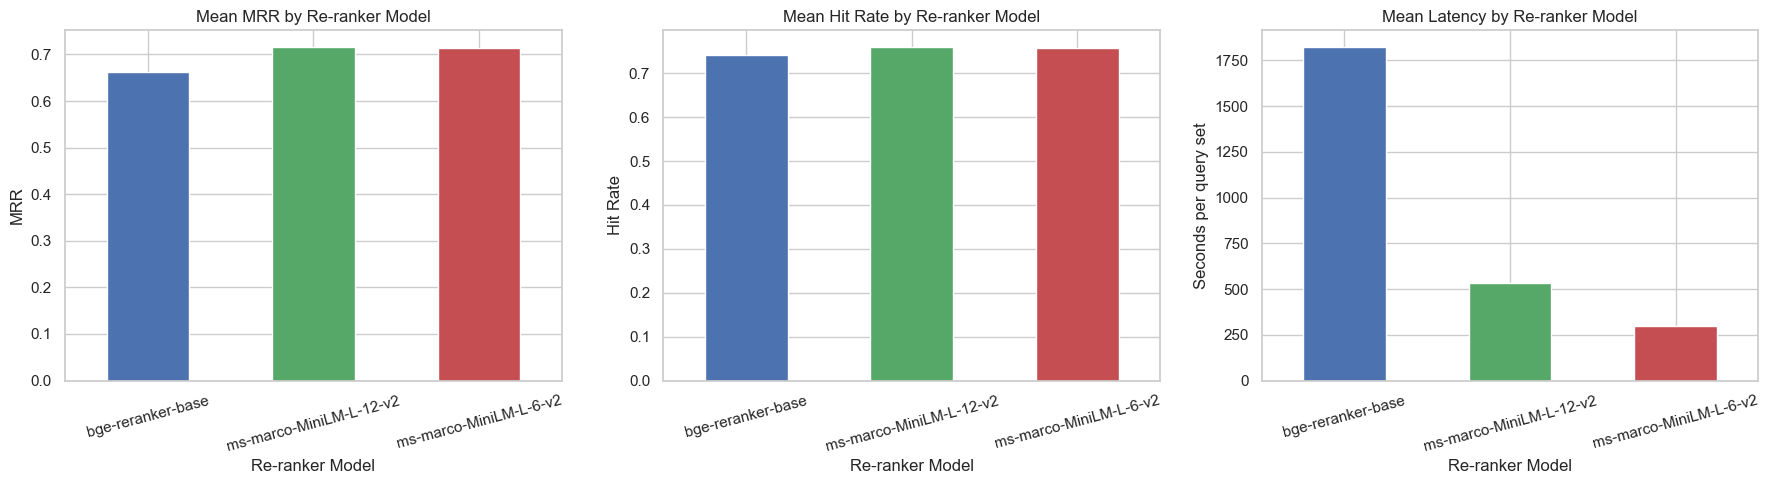

Saved: notebooks/reranker_model_comparison.png


In [25]:
# --- Visualization: Re-ranker model comparison ---
import matplotlib.pyplot as plt

# Filter to reranker configs only
df_rr = df_combined[df_combined["Re-ranker Model"] != "N/A"].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Mean MRR per re-ranker model
rr_means = df_rr.groupby("Re-ranker Model")[["MRR", "Hit Rate"]].mean()
rr_means["MRR"].plot(kind="bar", ax=axes[0], color=["#4C72B0", "#55A868", "#C44E52"])
axes[0].set_title("Mean MRR by Re-ranker Model")
axes[0].set_ylabel("MRR")
axes[0].tick_params(axis='x', rotation=15)

# Plot 2: Mean Hit Rate per re-ranker model
rr_means["Hit Rate"].plot(kind="bar", ax=axes[1], color=["#4C72B0", "#55A868", "#C44E52"])
axes[1].set_title("Mean Hit Rate by Re-ranker Model")
axes[1].set_ylabel("Hit Rate")
axes[1].tick_params(axis='x', rotation=15)

# Plot 3: Mean latency per re-ranker model
rr_latency = df_rr.groupby("Re-ranker Model")["Time (s)"].mean()
rr_latency.plot(kind="bar", ax=axes[2], color=["#4C72B0", "#55A868", "#C44E52"])
axes[2].set_title("Mean Latency by Re-ranker Model")
axes[2].set_ylabel("Seconds per query set")
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig("notebooks/reranker_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: notebooks/reranker_model_comparison.png")

Heatmaps using best re-ranker: ms-marco-MiniLM-L-6-v2


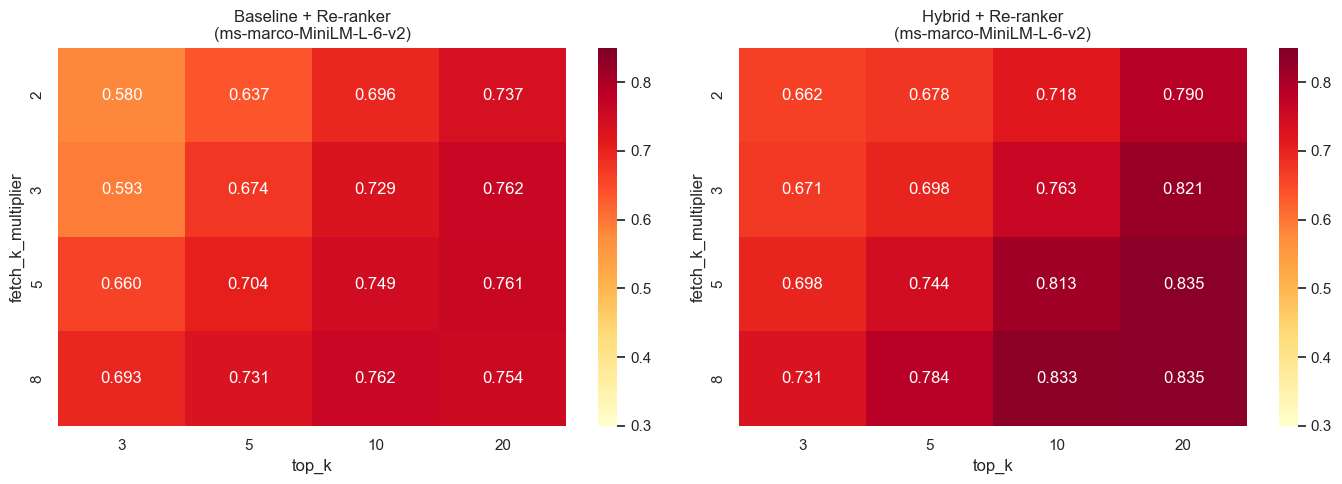

Saved: notebooks/combined_sweep_heatmap.png


In [26]:
# --- Visualization: Heatmap of MRR across top_k x fetch_k_mult ---
import matplotlib.pyplot as plt
import seaborn as sns

# Use the best re-ranker model for detailed heatmaps
best_rr = df_rr.loc[df_rr["MRR"].idxmax(), "Re-ranker Model"]
print(f"Heatmaps using best re-ranker: {best_rr}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, tech_name in enumerate(["Baseline + Re-ranker", "Hybrid + Re-ranker"]):
    subset = df_rr[
        (df_rr["Technique"] == tech_name) &
        (df_rr["Re-ranker Model"] == best_rr)
    ]
    pivot = subset.pivot_table(
        index="fetch_k_mult", columns="top_k", values="MRR", aggfunc="first"
    )
    sns.heatmap(
        pivot, annot=True, fmt=".3f", cmap="YlOrRd",
        ax=axes[idx], vmin=0.3, vmax=0.85,
    )
    axes[idx].set_title(f"{tech_name}\n({best_rr})")
    axes[idx].set_xlabel("top_k")
    axes[idx].set_ylabel("fetch_k_multiplier")

plt.tight_layout()
plt.savefig("notebooks/combined_sweep_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: notebooks/combined_sweep_heatmap.png")

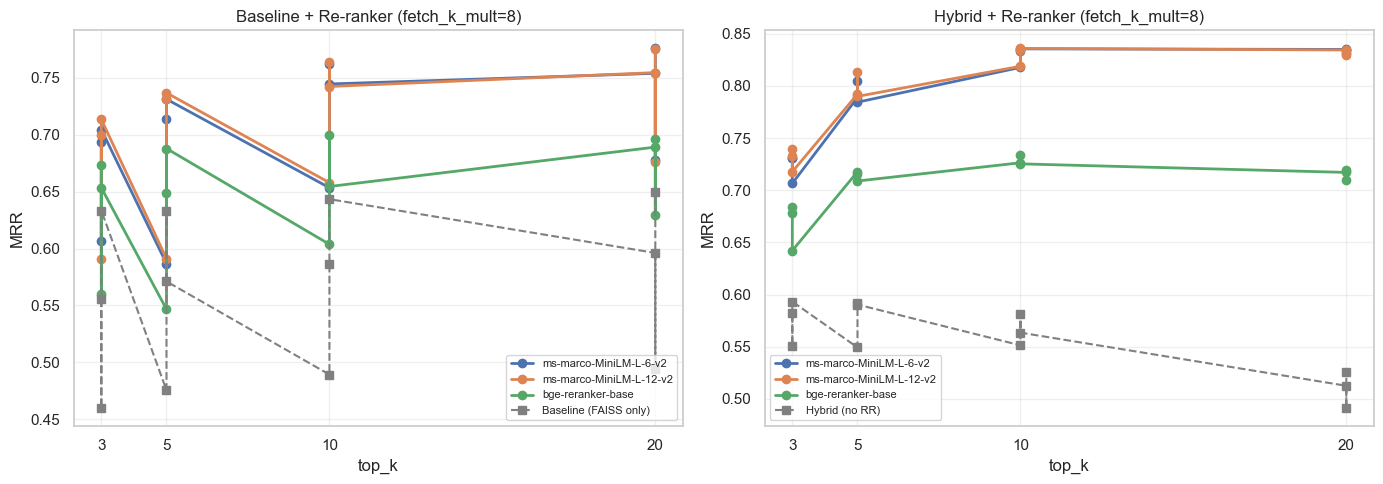

Saved: notebooks/combined_sweep_topk_curves.png


In [27]:
# --- Visualization: MRR curves across top_k for each re-ranker model ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Use best fetch_k_mult (8) for clean comparison
best_mult = 8

for idx, tech_name in enumerate(["Baseline + Re-ranker", "Hybrid + Re-ranker"]):
    ax = axes[idx]
    for rr_model in df_rr["Re-ranker Model"].unique():
        subset = df_rr[
            (df_rr["Technique"] == tech_name) &
            (df_rr["Re-ranker Model"] == rr_model) &
            (df_rr["fetch_k_mult"] == best_mult)
        ].sort_values("top_k")
        ax.plot(subset["top_k"], subset["MRR"], marker="o", label=rr_model, linewidth=2)

    # Add no-reranker baseline for reference
    norr_tech = "Baseline (FAISS only)" if "Baseline" in tech_name else "Hybrid (no RR)"
    norr_subset = df_combined[
        (df_combined["Technique"] == norr_tech) &
        (df_combined["Re-ranker Model"] == "N/A")
    ].sort_values("top_k")
    if not norr_subset.empty:
        ax.plot(norr_subset["top_k"], norr_subset["MRR"], marker="s",
                linestyle="--", color="gray", label=norr_tech, linewidth=1.5)

    ax.set_title(f"{tech_name} (fetch_k_mult={best_mult})")
    ax.set_xlabel("top_k")
    ax.set_ylabel("MRR")
    ax.legend(fontsize=8)
    ax.set_xticks([3, 5, 10, 20])
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("notebooks/combined_sweep_topk_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: notebooks/combined_sweep_topk_curves.png")

## 7.5 LLM-as-a-Judge Evaluation

Traditional retrieval metrics (Precision@k, MRR, Hit Rate) only measure whether the **correct chunks** were found. They say nothing about response quality.

This section uses **DeepEval** with two LLM judges (Claude Haiku and GPT-4o-mini) to score each RAG response on four metrics:
- **Faithfulness**: Are the claims in the response supported by the retrieved context?
- **Answer Relevancy**: Does the response actually address the query?
- **Contextual Precision**: Are the relevant context items ranked higher?
- **Contextual Recall**: Does the context contain everything needed to answer correctly?

The judge evaluates the **best configuration** found in Section 7.5.

In [31]:
# --- LLM-as-a-Judge: Setup ---
import nest_asyncio
nest_asyncio.apply()  # deepeval uses asyncio internally; prevents event-loop conflicts in Jupyter
import os

from deepeval.metrics import (
    FaithfulnessMetric,
    AnswerRelevancyMetric,
    ContextualPrecisionMetric,
    ContextualRecallMetric,
)
from deepeval.test_case import LLMTestCase
from deepeval.models import AnthropicModel, GPTModel

judge_anthropic = AnthropicModel(
    model="claude-sonnet-4-6",
    api_key=os.getenv("ANTHROPIC_API_KEY"),
)
print(f"Anthropic judge: {judge_anthropic.get_model_name()}")

_openai_key = os.getenv("OPENAI_API_KEY")
judge_openai = GPTModel(model="gpt-4o-mini", api_key=_openai_key) if _openai_key else None
if judge_openai:
    print(f"OpenAI judge: {judge_openai.get_model_name()}")
else:
    print("OPENAI_API_KEY not set â€” OpenAI judge will be skipped.")

# Representative queries across all types — selected by type for robustness
_judge_direct   = [e for e in TEST_SET if e["type"] == "direct"]
_judge_semantic = [e for e in TEST_SET if e["type"] == "semantic"]
_judge_partial  = [e for e in TEST_SET if e["type"] == "partial"]
_judge_ambig    = [e for e in TEST_SET if e["type"] == "ambiguous"]

JUDGE_QUERIES = (
    _judge_direct[:3]   +   # 3 direct
    _judge_semantic[:3] +   # 3 semantic
    _judge_partial[:2]  +   # 2 partial
    _judge_ambig[:2]        # 2 ambiguous
)  # 10 queries total
JUDGE_METRICS = ["Faithfulness", "Answer Relevancy", "Context Precision", "Context Recall"]

print(f"\nJudge queries: {len(JUDGE_QUERIES)}")
for i, q in enumerate(JUDGE_QUERIES, 1):
    print(f"  {i}. [{q['type']}] {q['query'][:60]}")


Anthropic judge: claude-sonnet-4-6 (Anthropic)
OpenAI judge: gpt-4o-mini

Judge queries: 10
  1. [direct] never gonna give you up never gonna let you down
  2. [direct] I came in like a wrecking ball
  3. [direct] is this the real life is this just fantasy
  4. [semantic] pop song where she feels pretty without makeup and her heart
  5. [semantic] inspirational song about keeping your head up when things ar
  6. [semantic] hip hop song bragging about staying humble, telling everyone
  7. [partial] the song that goes like butterfly something sugar baby
  8. [partial] song about good vibrations with a funky beat
  9. [ambiguous] emotional ballad about no gold in this river, drowning in si
  10. [ambiguous] country ballad about wishing for just one tear running down 


In [32]:
# --- LLM-as-a-Judge: Run Evaluation ---
judge_results_anthropic = load_ckpt("judge_anthropic") or []
judge_results_openai = load_ckpt("judge_openai") or []

# Auto-derive best config from the combined sweep (Section 7.5 above)
_best = df_combined.sort_values("MRR", ascending=False).iloc[0]
_technique = _best["Technique"]
JUDGE_USE_HYBRID   = "Hybrid" in _technique
JUDGE_USE_RERANKER = "Re-ranker" in _technique
JUDGE_USE_HYDE     = "HyDE" in _technique
JUDGE_TOP_K        = int(_best["top_k"])
_FETCH             = str(_best["fetch_k_mult"])
JUDGE_FETCH_MULT   = int(_FETCH) if _FETCH != "N/A" else 3
_RR_MODEL_MAP = {
    "ms-marco-MiniLM-L-6-v2":  "cross-encoder/ms-marco-MiniLM-L-6-v2",
    "ms-marco-MiniLM-L-12-v2": "cross-encoder/ms-marco-MiniLM-L-12-v2",
    "bge-reranker-base":        "BAAI/bge-reranker-base",
}
_rr_short      = str(_best["Re-ranker Model"])
JUDGE_RR_MODEL = _RR_MODEL_MAP.get(_rr_short, "cross-encoder/ms-marco-MiniLM-L-6-v2")

print(f"Best config (MRR={_best['MRR']:.3f}): {_technique}")
print(f"  top_k={JUDGE_TOP_K}, fetch_mult={JUDGE_FETCH_MULT}, reranker={_rr_short}")

# Load or build test-case inputs (saves ~10 pipeline queries on re-run)
_judge_inputs = load_ckpt("judge_inputs")
if _judge_inputs is None:
    pipeline_judge = QueryPipeline(
        embedding_model="all-MiniLM-L6-v2",
        llm_backend="anthropic",
        reranker_model=JUDGE_RR_MODEL,
    )

    print("Building test cases (running RAG pipeline)...")
    _judge_inputs = []
    for entry in JUDGE_QUERIES:
        print(f"  {entry['query'][:55]}...")
        result = pipeline_judge.query(
            entry["query"],
            top_k=JUDGE_TOP_K,
            use_hybrid=JUDGE_USE_HYBRID,
            use_reranker=JUDGE_USE_RERANKER,
            use_hyde=JUDGE_USE_HYDE,
            fetch_k_multiplier=JUDGE_FETCH_MULT,
        )

        context_texts = [
            f"[{song['title']} by {song['artist']}]\n{chunk['text']}"
            for song in result["retrieval_results"]
            for chunk in song["chunks"]
        ][:15]

        llm_resp = result["llm_response"]
        actual = llm_resp.summary
        if llm_resp.matches:
            for m in llm_resp.matches:
                actual += f"\n\n{m.title} by {m.artist}: {m.explanation}"

        expected = (
            f"The correct answer is '{entry['expected_title']}' by {entry['expected_artist']}. "
            f"The retrieved context should contain lyrics or metadata from this song that are "
            f"semantically relevant to the query: \"{entry['query']}\". "
            f"A good response identifies the correct song, explains why its lyrics match the query, "
            f"and quotes or paraphrases relevant lyric content."
        )

        _judge_inputs.append({
            "query": entry["query"],
            "actual_output": actual,
            "retrieval_context": context_texts,
            "expected_output": expected,
        })

    save_ckpt("judge_inputs", _judge_inputs)

test_cases = [
    LLMTestCase(
        input=d["query"],
        actual_output=d["actual_output"],
        retrieval_context=d["retrieval_context"],
        expected_output=d["expected_output"],
    )
    for d in _judge_inputs
]
print(f"\nTest cases ready: {len(test_cases)}")


import time as _time


def _run_judge(judge_model, judge_name, results_list):
    print(f"\n{'='*60}\nJudge: {judge_name}\n{'='*60}")
    metrics = {
        "Faithfulness": FaithfulnessMetric(model=judge_model, threshold=0.7),
        "Answer Relevancy": AnswerRelevancyMetric(model=judge_model, threshold=0.7),
        "Context Precision": ContextualPrecisionMetric(model=judge_model, threshold=0.7),
        "Context Recall": ContextualRecallMetric(model=judge_model, threshold=0.7),
    }
    for i, (tc, entry) in enumerate(zip(test_cases, JUDGE_QUERIES)):
        print(f"  Query {i+1}/{len(test_cases)}: {entry['query'][:50]}...")
        scores = {}
        for metric_name, metric in metrics.items():
            last_exc = None
            for attempt in range(3):
                try:
                    metric.measure(tc)
                    scores[metric_name] = round(metric.score, 3)
                    print(f"    {metric_name}: {metric.score:.3f}")
                    last_exc = None
                    break
                except Exception as e:
                    last_exc = e
                    if attempt < 2:
                        _time.sleep(2 ** attempt)
            if last_exc is not None:
                scores[metric_name] = None
                print(f"    {metric_name}: ERROR - {last_exc}")
        results_list.append({
            "query": entry["query"],
            "type": entry["type"],
            "expected": f"{entry['expected_title']} by {entry['expected_artist']}",
            **scores,
        })
    print(f"\n{judge_name} evaluation complete.")


if len(judge_results_anthropic) < len(JUDGE_QUERIES):
    judge_results_anthropic = []
    _run_judge(judge_anthropic, "Claude Sonnet (Anthropic)", judge_results_anthropic)
    save_ckpt("judge_anthropic", judge_results_anthropic)
else:
    print("[ckpt] Anthropic judge results already complete — skipping")

if judge_openai:
    if len(judge_results_openai) < len(JUDGE_QUERIES):
        judge_results_openai = []
        _run_judge(judge_openai, "GPT-4o-mini (OpenAI)", judge_results_openai)
        save_ckpt("judge_openai", judge_results_openai)
    else:
        print("[ckpt] OpenAI judge results already complete — skipping")
else:
    print("\nOpenAI judge skipped — OPENAI_API_KEY not set.")


2026-05-11 09:33:42,021 [INFO] Loading FAISS index from C:\Users\kapsiss\Desktop\Projects\RAG system\data\processed\faiss.index


[ckpt] loaded 'judge_openai' — skipping computation
Best config (MRR=0.836): Hybrid + Re-ranker
  top_k=20, fetch_mult=5, reranker=ms-marco-MiniLM-L-6-v2


2026-05-11 09:33:47,747 [INFO] Loading BM25 index from C:\Users\kapsiss\Desktop\Projects\RAG system\data\processed\bm25.pkl
2026-05-11 09:33:53,185 [INFO] Loading embedding model: all-MiniLM-L6-v2
Loading weights: 100%|████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 2138.86it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-05-11 09:34:07,073 [INFO] Query: 'never gonna give you up never gonna let you down' (top_k=20, hyde=False, hybrid=True, reranker=True, backend=anthropic)
2026-05-11 09:34:07,075 [INFO] Hybrid retrieval (FAISS + BM25 with RRF)...


Building test cases (running RAG pipeline)...
  never gonna give you up never gonna let you down...


2026-05-11 09:34:09,158 [INFO] Retrieved 100 chunks
2026-05-11 09:34:09,162 [INFO] Re-ranking with cross-encoder...
2026-05-11 09:34:09,168 [INFO] Loading cross-encoder model: cross-encoder/ms-marco-MiniLM-L-6-v2
Loading weights: 100%|████████████████████████████████████████████████████████████| 105/105 [00:00<00:00, 2014.37it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-05-11 09:34:22,636 [INFO] Re-ranked to top 20
2026-05-11 09:34:22,639 [INFO] Grouped into 9 unique song(s)
2026-05-11 09:34:27,826 [INFO] LLM confidence: high, matches: 3
2026-05-11 09:34:27,836 [INFO] Query: 'I came in like a wrecking ball' (top_k=20, hyde=False, hybrid=True, reranker=True, backend=anthropic)
2

...

    Context Recall: 1.000
  Query 10/10: country ballad about wishing for just one tear run...


    Faithfulness: 1.000


    Answer Relevancy: 0.923


    Context Precision: ERROR - Evaluation LLM outputted an invalid JSON. Please use a better evaluation model.


    Context Recall: 1.000

Claude Sonnet (Anthropic) evaluation complete.
[ckpt] saved judge_anthropic
[ckpt] OpenAI judge results already complete — skipping



Judge: Claude Sonnet (Anthropic)

  [direct] never gonna give you up never gonna let you down
  Expected: Never Gonna Give You Up by Rick Astley
    Faithfulness          â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ  1.000
    Answer Relevancy      â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ  1.000
    Context Precision                         ERROR
    Context Recall        â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ  1.000

  [direct] I came in like a wrecking ball
  Expected: Wrecking Ball by Miley Cyrus
    Faithfulness          â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ  1.000
    Answer Relevancy      â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–‘â–‘â–‘  0.857
    Context Precision     â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ  1.000
    Context Recall                            ERROR

  [direct] is this the real life is this just fantasy
  Expected: Bohemian Rhapsody by Queen
    Fait

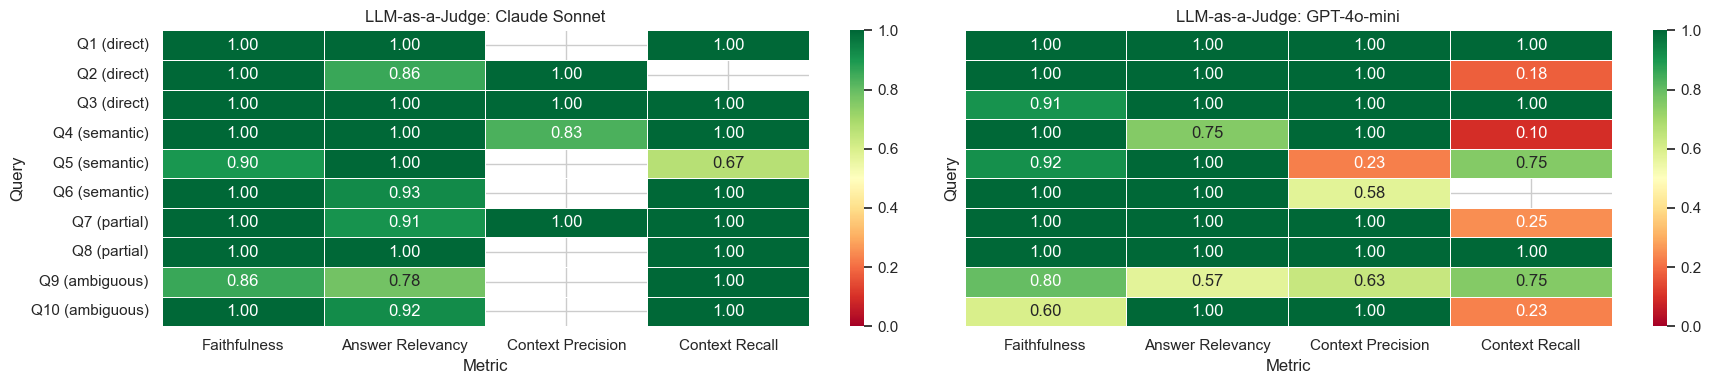

Saved: notebooks/llm_judge_scores.png

TABLE: Inter-Judge Agreement (Claude Sonnet vs GPT-4o-mini)
  Metric                 Claude Sonnet  GPT-4o-mini    Delta
----------------------------------------------------------
  Faithfulness                  0.976        0.923  -0.053
  Answer Relevancy              0.940        0.932  -0.008
  Context Precision             0.958        0.844  -0.114
  Context Recall                0.963        0.584  -0.379

TABLE: LLM-as-a-Judge Scores (Claude Sonnet judge)
Suitable for thesis appendix.
     type                                          expected  Faithfulness  Answer Relevancy  Context Precision  Context Recall
   direct            Never Gonna Give You Up by Rick Astley         1.000             1.000                NaN           1.000
   direct                      Wrecking Ball by Miley Cyrus         1.000             0.857              1.000             NaN
   direct                        Bohemian Rhapsody by Queen         1.000         

In [33]:
# --- LLM-as-a-Judge: Results ---

def _display_judge_results(judge_results, judge_name):
    if not judge_results:
        print(f"\n{judge_name}: No results.")
        return None
    df = pd.DataFrame(judge_results)
    print(f"\n{'='*80}\nJudge: {judge_name}\n{'='*80}")
    for _, row in df.iterrows():
        print(f"\n  [{row['type']}] {row['query'][:60]}")
        print(f"  Expected: {row['expected']}")
        for m in JUDGE_METRICS:
            val = row[m]
            if val is not None and not pd.isna(val):
                bar = "â–ˆ" * int(val * 20) + "â–‘" * (20 - int(val * 20))
                print(f"    {m:20s}  {bar}  {val:.3f}")
            else:
                print(f"    {m:20s}  {'ERROR':>25s}")
    print(f"\nAverages ({judge_name}):")
    for m in JUDGE_METRICS:
        valid = [r[m] for r in judge_results if r[m] is not None and not pd.isna(r[m])]
        avg = sum(valid) / len(valid) if valid else None
        print(f"  {m:20s}  {avg:.3f}" if avg is not None else f"  {m:20s}  N/A")
    return df


df_anthropic = _display_judge_results(judge_results_anthropic, "Claude Sonnet (Anthropic)")
df_openai = _display_judge_results(judge_results_openai, "GPT-4o-mini (OpenAI)")

# --- Side-by-side heatmaps ---
judges_with_data = [
    (df, name) for df, name in
    [(df_anthropic, "Claude Sonnet"), (df_openai, "GPT-4o-mini")]
    if df is not None and len(df) > 0
]

if judges_with_data:
    n = len(judges_with_data)
    fig, axes = plt.subplots(1, n, figsize=(9 * n, 4), sharey=(n > 1))
    if n == 1:
        axes = [axes]
    for ax, (df, name) in zip(axes, judges_with_data):
        df_plot = df[JUDGE_METRICS].apply(pd.to_numeric, errors="coerce")
        df_plot.index = [f"Q{i+1} ({row['type']})" for i, row in df.iterrows()]
        sns.heatmap(df_plot, annot=True, fmt=".2f", cmap="RdYlGn",
                    vmin=0, vmax=1, ax=ax, linewidths=0.5)
        ax.set_title(f"LLM-as-a-Judge: {name}")
        ax.set_xlabel("Metric")
        ax.set_ylabel("Query")
    plt.tight_layout()
    plt.savefig("notebooks/llm_judge_scores.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: notebooks/llm_judge_scores.png")

# --- Inter-judge comparison table ---
if df_anthropic is not None and df_openai is not None and len(df_anthropic) > 0 and len(df_openai) > 0:
    print("\n" + "=" * 70)
    print("TABLE: Inter-Judge Agreement (Claude Sonnet vs GPT-4o-mini)")
    print("=" * 70)
    print(f"  {'Metric':<22} {'Claude Sonnet':>12} {'GPT-4o-mini':>12} {'Delta':>8}")
    print("-" * 58)
    for m in JUDGE_METRICS:
        a_vals = [r[m] for r in judge_results_anthropic if r[m] is not None]
        o_vals = [r[m] for r in judge_results_openai if r[m] is not None]
        a_avg = sum(a_vals) / len(a_vals) if a_vals else None
        o_avg = sum(o_vals) / len(o_vals) if o_vals else None
        if a_avg is not None and o_avg is not None:
            delta = o_avg - a_avg
            sign = "+" if delta >= 0 else ""
            print(f"  {m:<22} {a_avg:>12.3f} {o_avg:>12.3f} {sign}{delta:>7.3f}")
        else:
            print(f"  {m:<22} {'N/A':>12} {'N/A':>12} {'N/A':>8}")

# --- Thesis-ready table (Anthropic judge as primary) ---
if df_anthropic is not None and len(df_anthropic) > 0:
    print("\n" + "=" * 70)
    print("TABLE: LLM-as-a-Judge Scores (Claude Sonnet judge)")
    print("Suitable for thesis appendix.")
    print("=" * 70)
    print(df_anthropic[["type", "expected"] + JUDGE_METRICS].to_string(index=False))

if not judge_results_anthropic and not judge_results_openai:
    print("No judge results to display.")


## 7.6 Contextual Embedding Ablation

Compares retrieval quality between **contextual** (metadata header prepended) and **non-contextual** (raw lyrics only) embeddings. This isolates the contribution of Anthropic's Contextual Retrieval technique.

**Requires:** Non-contextual index built with `--skip-contextual` in Phase 3. Skipped automatically if the index is not found.

In [36]:
# --- Contextual Embedding Ablation ---
import logging
import time
import pandas as pd

# Identify contextual vs non-contextual pipeline pairs
ABLATION_PAIRS = [
    ("all-MiniLM-L6-v2", "MiniLM-noctx"),
    ("bge-small-en-v1.5", "bge-noctx"),
]

# Filter to pairs where both pipelines are available
available_pairs = [
    (ctx, noctx) for ctx, noctx in ABLATION_PAIRS
    if ctx in pipelines and noctx in pipelines
]

if not available_pairs:
    print("No contextual/non-contextual pipeline pairs available.")
    print("Build a non-contextual index first:")
    print("  .venv\\Scripts\\python pipeline\\embedding.py --skip-contextual")
else:
    _ql = logging.getLogger('pipeline.query')
    _orig_level = _ql.level
    _ql.setLevel(logging.WARNING)

    ablation_results = []

    for ctx_name, noctx_name in available_pairs:
        print(f"\nAblation: {ctx_name} (contextual) vs {noctx_name} (raw)")
        print("=" * 60)

        for pipeline_label, pipeline_key in [("Contextual", ctx_name), ("Non-contextual", noctx_name)]:
            p = pipelines[pipeline_key]
            for technique in [t for t in TECHNIQUE_GRID if not t["use_hyde"]]:
                t_name = technique["name"]
                start = time.time()
                result = evaluate_pipeline(
                    p, TEST_SET, top_k=TOP_K,
                    use_hyde=technique["use_hyde"],
                    use_hybrid=technique["use_hybrid"],
                    use_reranker=technique["use_reranker"],
                    skip_llm=True,
                )
                elapsed = time.time() - start
                ablation_results.append({
                    "Model": ctx_name,
                    "Embedding": pipeline_label,
                    "Technique": t_name,
                    "MRR": result["mrr"],
                    "Hit Rate": result["hit_rate"],
                    "Precision@k": result["precision_at_k"],
                    "Time (s)": round(elapsed, 1),
                })
                print(f"  {pipeline_label:15s} | {t_name:30s} | MRR={result['mrr']:.3f}")

    _ql.setLevel(_orig_level)

    df_ablation = pd.DataFrame(ablation_results)
    print("\n" + "=" * 80)
    print("ABLATION RESULTS")
    print("=" * 80)
    print(df_ablation.to_string(index=False))


Ablation: all-MiniLM-L6-v2 (contextual) vs MiniLM-noctx (raw)
  Contextual      | Baseline (FAISS only)          | MRR=0.571
  Contextual      | + Re-ranker                    | MRR=0.674
  Contextual      | + Hybrid                       | MRR=0.590
  Contextual      | + Hybrid + Re-ranker           | MRR=0.698


2026-05-11 11:12:13,564 [INFO] Loading cross-encoder model: cross-encoder/ms-marco-MiniLM-L-6-v2


  Non-contextual  | Baseline (FAISS only)          | MRR=0.471


Loading weights: 100%|███████████████████████████████████████████████████████████| 105/105 [00:00<00:00, 10403.28it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Non-contextual  | + Re-ranker                    | MRR=0.598
  Non-contextual  | + Hybrid                       | MRR=0.513
  Non-contextual  | + Hybrid + Re-ranker           | MRR=0.684

Ablation: bge-small-en-v1.5 (contextual) vs bge-noctx (raw)


...

  Contextual      | + Re-ranker                    | MRR=0.580
  Contextual      | + Hybrid                       | MRR=0.549
  Contextual      | + Hybrid + Re-ranker           | MRR=0.709


2026-05-11 11:25:11,845 [INFO] Loading cross-encoder model: cross-encoder/ms-marco-MiniLM-L-6-v2


  Non-contextual  | Baseline (FAISS only)          | MRR=0.558


Loading weights: 100%|█████████████████████████████████████████████████████████████| 105/105 [00:00<00:00, 979.11it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Non-contextual  | + Re-ranker                    | MRR=0.683
  Non-contextual  | + Hybrid                       | MRR=0.556
  Non-contextual  | + Hybrid + Re-ranker           | MRR=0.653

ABLATION RESULTS
            Model      Embedding             Technique      MRR  Hit Rate  Precision@k  Time (s)
 all-MiniLM-L6-v2     Contextual Baseline (FAISS only) 0.571111  0.626667     0.626667       3.2
 all-MiniLM-L6-v2     Contextual           + Re-ranker 0.674444  0.706667     0.706667      69.7
 all-MiniLM-L6-v2     Contextual              + Hybrid 0.590444  0.693333     0.693333     117.0
 all-MiniLM-L6-v2     Contextual  + Hybrid + Re-ranker 0.697778  0.733333     0.733333     198.9
 all-MiniLM-L6-v2 Non-contextual Baseline (FAISS only) 0.471111  0.533333     0.533333       5.8
 all-MiniLM-L6-v2 Non-contextual           + Re-ranker 0.597778  0.626667     0.626667      78.4
 all-MiniLM-L6-v2 Non-contextual              + Hybrid 0.513333  0.640000     0.640000     103.5
 all-MiniLM-L6-v2


MRR DELTA: Contextual - Non-contextual (all-MiniLM-L6-v2)
--------------------------------------------------
  Baseline (FAISS only)                +0.100
  + Re-ranker                          +0.077
  + Hybrid                             +0.077
  + Hybrid + Re-ranker                 +0.013
  Average                              +0.067


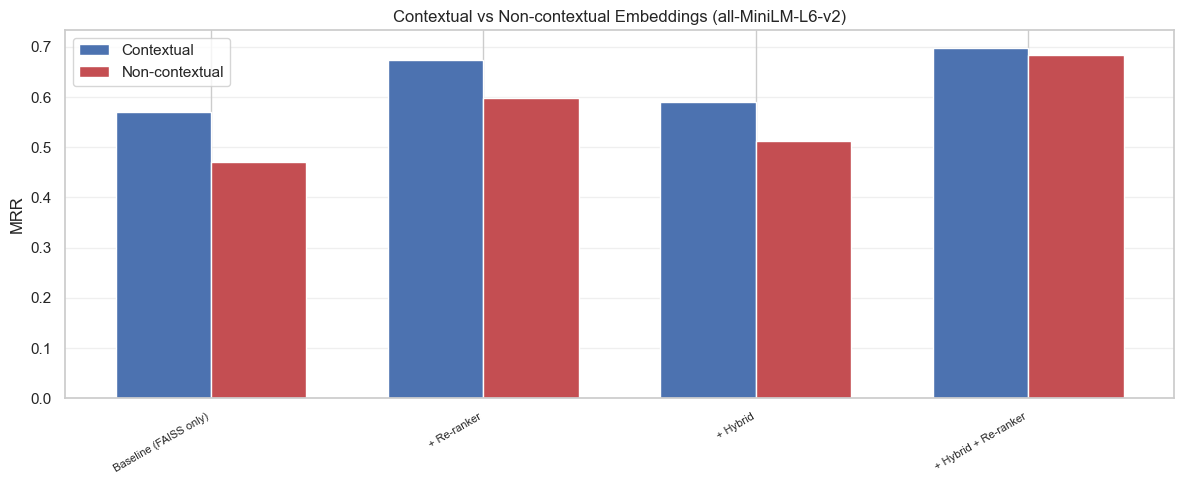

Saved: notebooks/contextual_ablation.png

MRR DELTA: Contextual - Non-contextual (bge-small-en-v1.5)
--------------------------------------------------
  Baseline (FAISS only)                -0.082
  + Re-ranker                          -0.103
  + Hybrid                             -0.007
  + Hybrid + Re-ranker                 +0.056
  Average                              -0.034


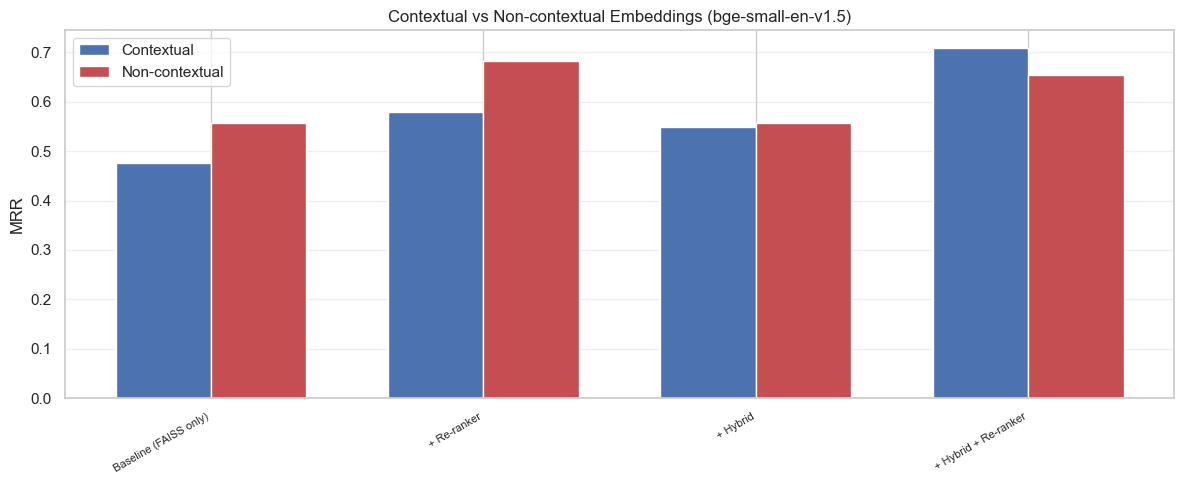

Saved: notebooks/contextual_ablation.png


In [37]:
# --- Ablation: MRR delta and visualization ---
import matplotlib.pyplot as plt
import numpy as np

if available_pairs:
    for ctx_name, _ in available_pairs:
        subset = df_ablation[df_ablation["Model"] == ctx_name]
        ctx_mrr = subset[subset["Embedding"] == "Contextual"].set_index("Technique")["MRR"]
        noctx_mrr = subset[subset["Embedding"] == "Non-contextual"].set_index("Technique")["MRR"]
        delta = ctx_mrr - noctx_mrr

        print(f"\nMRR DELTA: Contextual - Non-contextual ({ctx_name})")
        print("-" * 50)
        for tech, d in delta.items():
            print(f"  {tech:35s}  {d:+.3f}")
        print(f"  {'Average':35s}  {delta.mean():+.3f}")

        # Bar chart
        techniques = list(ctx_mrr.index)
        x = np.arange(len(techniques))
        width = 0.35

        fig, ax = plt.subplots(figsize=(12, 5))
        bars1 = ax.bar(x - width/2, ctx_mrr.values, width, label="Contextual", color="#4C72B0")
        bars2 = ax.bar(x + width/2, noctx_mrr.values, width, label="Non-contextual", color="#C44E52")

        ax.set_ylabel("MRR")
        ax.set_title(f"Contextual vs Non-contextual Embeddings ({ctx_name})")
        ax.set_xticks(x)
        ax.set_xticklabels(techniques, rotation=30, ha="right", fontsize=8)
        ax.legend()
        ax.grid(True, alpha=0.3, axis="y")

        plt.tight_layout()
        plt.savefig("notebooks/contextual_ablation.png", dpi=150, bbox_inches="tight")
        plt.show()
        print("Saved: notebooks/contextual_ablation.png")
else:
    print("Skipped: no ablation pairs available.")

## 7.7 Latency Profiling

End-to-end latency breakdown by pipeline stage: query embedding, FAISS search, BM25 search, RRF fusion, cross-encoder re-ranking. Uses 5 representative queries and averages across them.

2026-05-11 11:51:50,192 [INFO] Loading cross-encoder model: cross-encoder/ms-marco-MiniLM-L-6-v2
Loading weights: 100%|████████████████████████████████████████████████████████████| 105/105 [00:00<00:00, 1660.40it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


LATENCY PROFILE (average over 5 queries)
       Embedding Model        Config  Embed (ms)  FAISS (ms)  BM25 (ms)  RRF (ms)  Re-rank (ms)  Total (ms)
      all-MiniLM-L6-v2      Baseline        20.4        38.3        0.0       0.0           0.0        58.7
      all-MiniLM-L6-v2 Baseline + RR        17.4        23.2        0.0       0.0        1907.5      1948.1
      all-MiniLM-L6-v2        Hybrid       148.5        48.8     1886.9      56.8           0.0      2140.9
      all-MiniLM-L6-v2   Hybrid + RR        30.6        31.7     1609.7     150.3        4258.0      6080.3
     bge-small-en-v1.5      Baseline       189.6        53.6        0.0       0.0           0.0       243.2
     bge-small-en-v1.5 Baseline + RR       203.2        70.7        0.0       0.0        5657.5      5931.4
     bge-small-en-v1.5        Hybrid       725.0        51.8     3511.4     253.0           0.0      4541.2
     bge-small-en-v1.5   Hybrid + RR      1085.0        41.5     2356.5     297.2        6477.5

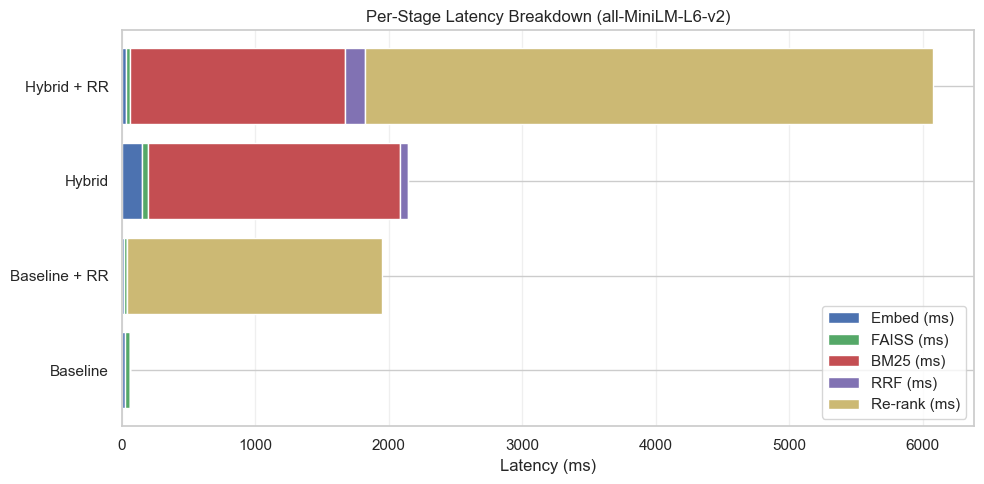

Saved: notebooks/latency_profile_all_MiniLM_L6_v2.png


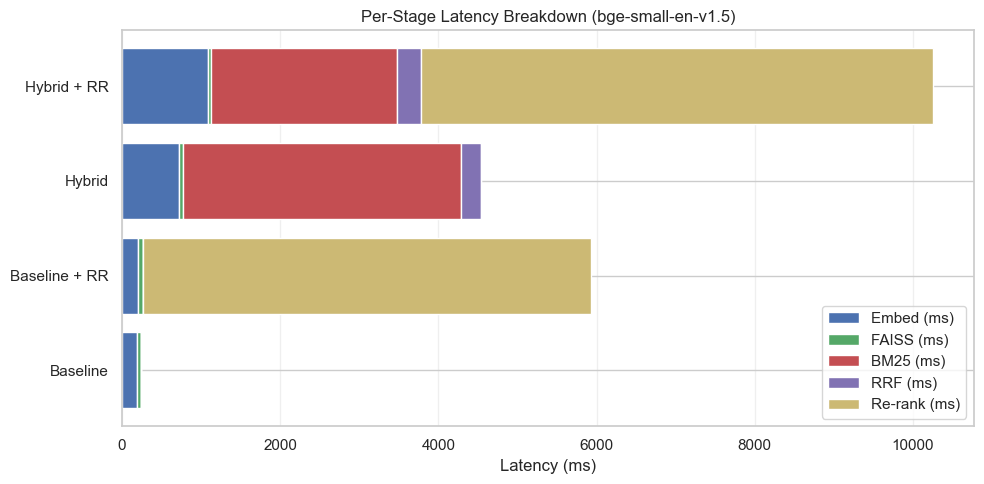

Saved: notebooks/latency_profile_bge_small_en_v1.5.png


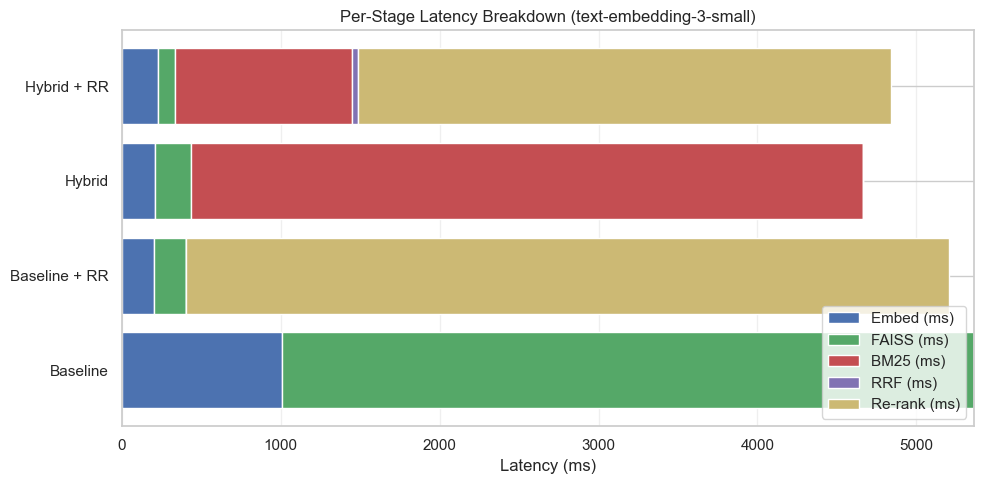

Saved: notebooks/latency_profile_text_embedding_3_small.png


In [38]:
# --- Latency Profiling (per embedding model) ---
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

latency_indices = [0, min(7, len(TEST_SET)-1), min(14, len(TEST_SET)-1),
                   min(20, len(TEST_SET)-1), min(24, len(TEST_SET)-1)]
LATENCY_QUERIES = [TEST_SET[i]['query'] for i in latency_indices]

LATENCY_CONFIGS = [
    {'name': 'Baseline',      'use_hybrid': False, 'use_reranker': False},
    {'name': 'Baseline + RR', 'use_hybrid': False, 'use_reranker': True},
    {'name': 'Hybrid',        'use_hybrid': True,  'use_reranker': False},
    {'name': 'Hybrid + RR',   'use_hybrid': True,  'use_reranker': True},
]

all_latency_rows = []

for emb_model_name, pipeline in sweep_pipelines.items():
    latency_rows = []

    for config in LATENCY_CONFIGS:
        embed_times, faiss_times, bm25_times, rrf_times, rerank_times = [], [], [], [], []

        for q in LATENCY_QUERIES:
            # Stage 1: Embed the query
            t0 = time.perf_counter()
            q_emb = pipeline._embed_text(q)
            t_embed = time.perf_counter() - t0
            embed_times.append(t_embed)

            # Stage 2: FAISS search
            top_k = 5
            fetch_k = top_k * 8 if config['use_reranker'] else top_k
            t0 = time.perf_counter()
            scores, indices = pipeline.index.search(q_emb, fetch_k)
            faiss_results = []
            for score, idx in zip(scores[0], indices[0]):
                if idx < 0:
                    continue
                entry = dict(pipeline.metadata[idx])
                entry['score'] = float(score)
                faiss_results.append(entry)
            t_faiss = time.perf_counter() - t0
            faiss_times.append(t_faiss)

            raw_results = faiss_results

            # Stage 3 & 4: BM25 + RRF (if hybrid)
            if config['use_hybrid'] and pipeline.bm25 is not None:
                t0 = time.perf_counter()
                bm25_results = pipeline.retrieve_bm25(q, top_k=fetch_k)
                t_bm25 = time.perf_counter() - t0
                bm25_times.append(t_bm25)

                t0 = time.perf_counter()
                raw_results = pipeline.retrieve_hybrid(q, top_k=fetch_k)
                t_hybrid_total = time.perf_counter() - t0
                t_rrf = max(t_hybrid_total - t_embed - t_faiss - t_bm25, 0)
                rrf_times.append(t_rrf)

            # Stage 5: Re-ranking (if enabled)
            if config['use_reranker']:
                reranker = pipeline._get_reranker()
                t0 = time.perf_counter()
                reranker.rerank(query=q, chunks=raw_results, top_k=top_k)
                t_rerank = time.perf_counter() - t0
                rerank_times.append(t_rerank)

        latency_rows.append({
            'Embedding Model': emb_model_name,
            'Config': config['name'],
            'Embed (ms)':   np.mean(embed_times)   * 1000,
            'FAISS (ms)':   np.mean(faiss_times)   * 1000,
            'BM25 (ms)':    np.mean(bm25_times)    * 1000 if bm25_times  else 0,
            'RRF (ms)':     np.mean(rrf_times)     * 1000 if rrf_times   else 0,
            'Re-rank (ms)': np.mean(rerank_times)  * 1000 if rerank_times else 0,
        })

    all_latency_rows.extend(latency_rows)

df_latency = pd.DataFrame(all_latency_rows)
stages = ['Embed (ms)', 'FAISS (ms)', 'BM25 (ms)', 'RRF (ms)', 'Re-rank (ms)']
df_latency['Total (ms)'] = df_latency[stages].sum(axis=1)

print('LATENCY PROFILE (average over 5 queries)')
print('=' * 90)
print(df_latency[['Embedding Model', 'Config'] + stages + ['Total (ms)']].round(1).to_string(index=False))

colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B3', '#CCB974']

for emb_model_name in df_latency['Embedding Model'].unique():
    df_m = df_latency[df_latency['Embedding Model'] == emb_model_name]
    fig, ax = plt.subplots(figsize=(10, 5))
    bottoms = np.zeros(len(df_m))
    for stage, color in zip(stages, colors):
        vals = df_m[stage].values
        ax.barh(df_m['Config'], vals, left=bottoms, label=stage, color=color)
        bottoms += vals
    ax.set_xlabel('Latency (ms)')
    ax.set_title(f'Per-Stage Latency Breakdown ({emb_model_name})')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    safe_name = emb_model_name.replace("/", "_").replace("-", "_")
    plt.savefig(f'notebooks/latency_profile_{safe_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: notebooks/latency_profile_{safe_name}.png')


## 7.8 Statistical Significance Testing

Tests whether the MRR improvement of the best configuration over the baseline is statistically significant. Uses the Wilcoxon signed-rank test (non-parametric, paired) and paired bootstrap resampling for confidence intervals.

In [39]:
# --- Statistical Significance (per embedding model) ---
import numpy as np
from scipy import stats

def get_rr_array(result):
    return np.array([
        1.0 / pq['rank'] if pq['rank'] is not None else 0.0
        for pq in result['per_query']
    ])

for emb_model_name in sweep_pipelines:
    model_results = {k: v for k, v in all_results.items() if k[0] == emb_model_name}
    if not model_results:
        print(f"[{emb_model_name}] No results found â€” skipping.")
        continue

    baseline_key = (emb_model_name, 'Baseline (FAISS only)')
    if baseline_key not in all_results:
        print(f"[{emb_model_name}] Baseline result missing â€” skipping.")
        continue

    best_key = max(model_results.items(), key=lambda x: x[1]['mrr'])[0]

    rr_baseline = get_rr_array(all_results[baseline_key])
    rr_best     = get_rr_array(all_results[best_key])

    print(f"\n{'='*60}")
    print(f"Model: {emb_model_name}")
    print(f"Comparing: {baseline_key[1]} vs {best_key[1]}")
    print(f"  Baseline MRR: {rr_baseline.mean():.3f}")
    print(f"  Best MRR:     {rr_best.mean():.3f}")
    print(f"  Delta:        {(rr_best - rr_baseline).mean():+.3f}")

    diff = rr_best - rr_baseline
    nonzero = diff[diff != 0]
    if len(nonzero) > 0:
        stat, p_value = stats.wilcoxon(nonzero)
        print(f"  Wilcoxon signed-rank test:")
        print(f"    Statistic: {stat:.1f}")
        print(f"    p-value:   {p_value:.4f}")
        print(f"    Significant at 0.05: {'YES' if p_value < 0.05 else 'NO'}")
        print(f"    Significant at 0.01: {'YES' if p_value < 0.01 else 'NO'}")
    else:
        print("  No differences between configs (all queries same rank).")

    # Paired bootstrap 95% CI
    n_boot = 10000
    np.random.seed(42)
    n = len(rr_baseline)
    boot_deltas = []
    for _ in range(n_boot):
        idx = np.random.choice(n, size=n, replace=True)
        boot_deltas.append(rr_best[idx].mean() - rr_baseline[idx].mean())
    boot_deltas = np.array(boot_deltas)
    ci_lower = np.percentile(boot_deltas, 2.5)
    ci_upper = np.percentile(boot_deltas, 97.5)
    print(f"  Paired Bootstrap (n={n_boot}):")
    print(f"    Mean delta:  {boot_deltas.mean():+.3f}")
    print(f"    95% CI:      [{ci_lower:+.3f}, {ci_upper:+.3f}]")
    print(f"    CI excludes zero: {'YES' if ci_lower > 0 or ci_upper < 0 else 'NO'}")



Model: all-MiniLM-L6-v2
Comparing: Baseline (FAISS only) vs + Hybrid + Re-ranker
  Baseline MRR: 0.571
  Best MRR:     0.698
  Delta:        +0.127
  Wilcoxon signed-rank test:
    Statistic: 116.0
    p-value:   0.0242
    Significant at 0.05: YES
    Significant at 0.01: NO
  Paired Bootstrap (n=10000):
    Mean delta:  +0.126
    95% CI:      [+0.013, +0.242]
    CI excludes zero: YES

Model: bge-small-en-v1.5
Comparing: Baseline (FAISS only) vs + Hybrid + Re-ranker
  Baseline MRR: 0.476
  Best MRR:     0.709
  Delta:        +0.233
  Wilcoxon signed-rank test:
    Statistic: 127.0
    p-value:   0.0007
    Significant at 0.05: YES
    Significant at 0.01: YES
  Paired Bootstrap (n=10000):
    Mean delta:  +0.232
    95% CI:      [+0.104, +0.362]
    CI excludes zero: YES

Model: text-embedding-3-small
Comparing: Baseline (FAISS only) vs + Hybrid + Re-ranker
  Baseline MRR: 0.633
  Best MRR:     0.687
  Delta:        +0.053
  Wilcoxon signed-rank test:
    Statistic: 124.5
    p-val

## 8. RAG vs. Pure LLM Baseline

Does retrieval actually help? This experiment answers that directly by comparing three conditions on the same 75 queries:

| Condition | How it works |
|-----------|---------------|
| **Pure LLM (Claude Haiku)** | Raw query â†’ Claude, no retrieved context |
| **Pure LLM (GPT-4o-mini)** | Raw query â†’ GPT-4o-mini, no retrieved context |
| **RAG + Claude Haiku (best config)** | Query â†’ retrieval â†’ Claude synthesis with context |

All three conditions are scored the same way: a hit is recorded when the model's final response contains the correct title and artist (same fuzzy normalization used throughout). This is an apples-to-apples comparison â€” both the pure LLM and the RAG pipeline go through Claude Haiku; the only difference is whether retrieved lyrics are included in the prompt.

**Note:** This runs 75 RAG + LLM queries on the best config in addition to the 75 Ã— 2 pure LLM calls â€” expect ~3-5 minutes total runtime.

Best RAG config: + Hybrid + Re-ranker
  use_hybrid=True, use_reranker=True, use_hyde=False


Loading weights: 100%|████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 3815.90it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Running 75 queries × 3 conditions...



2026-05-11 12:05:00,519 [INFO] Loading cross-encoder model: cross-encoder/ms-marco-MiniLM-L-6-v2
Loading weights: 100%|████████████████████████████████████████████████████████████| 105/105 [00:00<00:00, 3818.23it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  10/75 done...
  20/75 done...
  30/75 done...
  40/75 done...
  50/75 done...
  60/75 done...
  70/75 done...
Done.

[ckpt] saved llm_results
Overall Hit Rate â€” RAG vs. Pure LLM
  Claude Haiku (no retrieval)               ████░░░░░░░░░░░░░░░░░░░░░░░░░░  0.133
  GPT-4o-mini (no retrieval)                █████░░░░░░░░░░░░░░░░░░░░░░░░░  0.173
  RAG retrieval only (+ Hybrid + Re-ranker)  ██████████████████████░░░░░░░░  0.733
  RAG + Claude Haiku (+ Hybrid + Re-ranker)  ██████████████████████░░░░░░░░  0.747
  RAG + GPT-4o-mini (+ Hybrid + Re-ranker)  ████████████████████░░░░░░░░░░  0.693

RAG+Claude lift over Claude (no retrieval): +0.613
RAG+GPT    lift over GPT    (no retrieval): +0.520

Per-Query-Type Hit Rate:
  Type                Claude (no ctx)  GPT (no ctx)   RAG only  RAG+Claude  RAG+GPT
----------------------------------------------------------------------------------
  ambiguous                     0.000         0.000      0.667       0.667    0.556
  direct                  

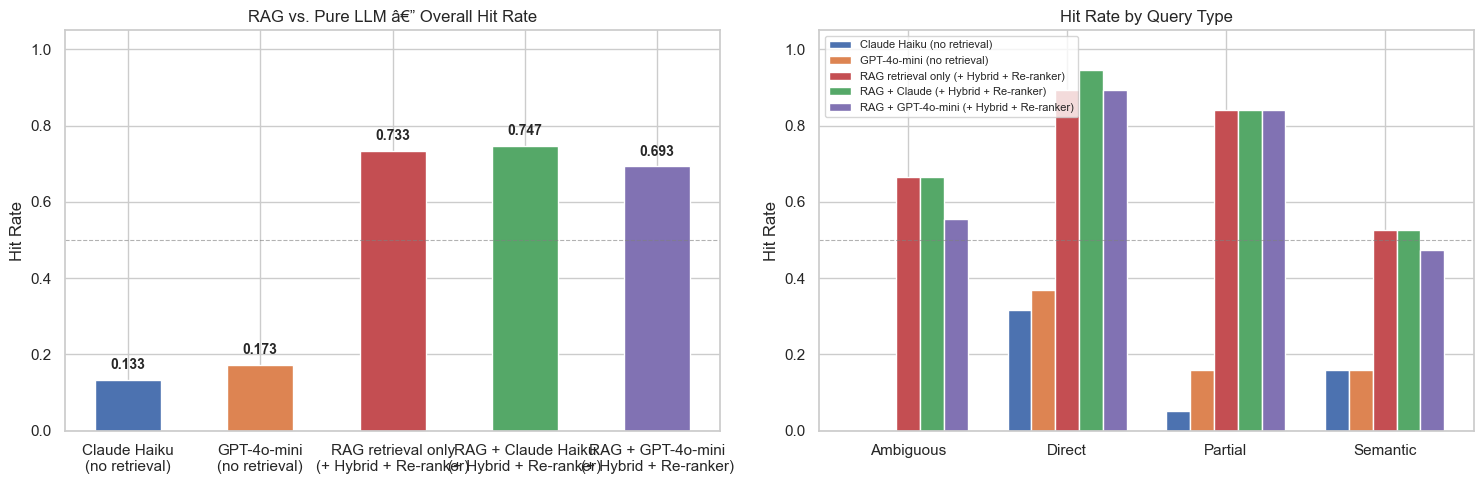

Saved: notebooks/rag_vs_llm_baseline.png

TABLE: RAG vs. Pure LLM Baseline â€” Hit Rate
  Condition                                  Hit Rate
----------------------------------------------------
  Claude Haiku (no retrieval)                   0.133
  GPT-4o-mini (no retrieval)                    0.173
  RAG retrieval only (+ Hybrid + Re-ranker)      0.733
  RAG + Claude Haiku (+ Hybrid + Re-ranker)      0.747
  RAG + GPT-4o-mini (+ Hybrid + Re-ranker)      0.693

  RAG+Claude lift vs Claude (no retrieval): +0.613
  RAG+GPT    lift vs GPT   (no retrieval): +0.520

  Per-query-type breakdown:
  Type                Claude (no ctx)  GPT (no ctx)   RAG only  RAG+Claude  RAG+GPT
----------------------------------------------------------------------------------
  ambiguous                     0.000         0.000      0.667       0.667    0.556
  direct                        0.316         0.368      0.895       0.947    0.895
  partial                       0.053         0.158      0.842     

In [41]:
# --- RAG vs. Pure LLM Baseline ---
import os
import time
import anthropic as _anthropic
from openai import OpenAI as _OpenAI

_SYSTEM_PROMPT = (
    "You are a music expert. The user will give you a lyric fragment, description, "
    "or partial memory of a song. Identify the most likely song. "
    "Reply with ONLY: Title by Artist — nothing else. No explanation, no punctuation beyond that."
)


def _ask_claude(client, query: str) -> str:
    msg = client.messages.create(
        model="claude-haiku-4-5-20251001",
        max_tokens=60,
        system=_SYSTEM_PROMPT,
        messages=[{"role": "user", "content": query}],
    )
    return msg.content[0].text.strip()


def _ask_gpt(client, query: str) -> str:
    resp = client.chat.completions.create(
        model="gpt-4o-mini",
        max_tokens=60,
        messages=[
            {"role": "system", "content": _SYSTEM_PROMPT},
            {"role": "user", "content": query},
        ],
    )
    return resp.choices[0].message.content.strip()


def _ask_gpt_with_context(client, query: str, retrieval_results: list) -> str:
    context_parts = []
    for song in retrieval_results:
        context_parts.append(f"Song: {song['title']} by {song['artist']}")
        for chunk in song["chunks"][:2]:
            context_parts.append(f"  Lyrics: {chunk['text'][:200]}")
    context = "\n".join(context_parts)
    system = (
        "You are a music search assistant. Based on the retrieved song excerpts, "
        "identify the best matching song for the user's query. "
        "Reply with ONLY: Title by Artist — nothing else."
    )
    resp = client.chat.completions.create(
        model="gpt-4o-mini", max_tokens=60,
        messages=[
            {"role": "system", "content": system},
            {"role": "user", "content": f"Query: {query}\n\nRetrieved songs:\n{context}"},
        ],
    )
    return resp.choices[0].message.content.strip()


def _is_hit_raw(response: str, expected_title: str, expected_artist: str) -> bool:
    resp_n = normalize(response)
    return normalize(expected_title) in resp_n and normalize(expected_artist) in resp_n


def _is_hit_rag(llm_response, expected_title: str, expected_artist: str) -> bool:
    et, ea = normalize(expected_title), normalize(expected_artist)
    for match in llm_response.matches:
        if et in normalize(match.title) and ea in normalize(match.artist):
            return True
    return False


# --- Determine best RAG config from Section 3 ---
default_model_name = list(pipelines.keys())[0]
best_rag_key = max(
    [k for k in all_results if k[0] == default_model_name],
    key=lambda k: all_results[k]["mrr"],
)
best_rag_label = best_rag_key[1]

# Parse technique flags from the label
_use_hybrid   = "Hybrid"    in best_rag_label
_use_reranker = "Re-ranker" in best_rag_label
_use_hyde     = "HyDE"      in best_rag_label
print(f"Best RAG config: {best_rag_label}")
print(f"  use_hybrid={_use_hybrid}, use_reranker={_use_reranker}, use_hyde={_use_hyde}")

llm_results = load_ckpt("llm_results")
if llm_results is None:
    # --- Initialise clients ---
    anthropic_client = _anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))
    openai_client    = _OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

    pipeline_rag = QueryPipeline(
        embedding_model="all-MiniLM-L6-v2",
        llm_backend="anthropic",
    )

    # --- Run all queries ---
    llm_results = {"claude": [], "gpt": [], "rag": [], "rag_gpt": []}

    print(f"\nRunning {len(TEST_SET)} queries × 3 conditions...\n")
    for i, entry in enumerate(TEST_SET):
        q  = entry["query"]
        et = entry["expected_title"]
        ea = entry["expected_artist"]
        qt = entry["type"]

        # Pure LLM — Claude Haiku (no retrieval)
        claude_resp = _ask_claude(anthropic_client, q)
        llm_results["claude"].append({
            "query": q, "type": qt, "expected_title": et, "expected_artist": ea,
            "response": claude_resp, "hit": _is_hit_raw(claude_resp, et, ea),
        })

        # Pure LLM — GPT-4o-mini (no retrieval)
        gpt_resp = _ask_gpt(openai_client, q)
        llm_results["gpt"].append({
            "query": q, "type": qt, "expected_title": et, "expected_artist": ea,
            "response": gpt_resp, "hit": _is_hit_raw(gpt_resp, et, ea),
        })

        # RAG + Claude Haiku (retrieval + LLM synthesis)
        try:
            rag_result = pipeline_rag.query(
                q, top_k=TOP_K,
                use_hybrid=_use_hybrid,
                use_reranker=_use_reranker,
                use_hyde=_use_hyde,
            )
            rag_hit = _is_hit_rag(rag_result["llm_response"], et, ea)
            _rag_retrieval = rag_result["retrieval_results"]
        except Exception:
            rag_hit = False
            _rag_retrieval = []

        llm_results["rag"].append({
            "query": q, "type": qt, "expected_title": et, "expected_artist": ea,
            "hit": rag_hit,
        })
        
        # RAG + GPT-4o-mini: reuse retrieval results, call GPT for synthesis
        rag_gpt_resp = _ask_gpt_with_context(openai_client, q, rag_result["retrieval_results"])
        llm_results["rag_gpt"].append({
            "query": q, "type": qt, "expected_title": et, "expected_artist": ea,
            "response": rag_gpt_resp, "hit": _is_hit_raw(rag_gpt_resp, et, ea),
        })

        if (i + 1) % 10 == 0:
            print(f"  {i+1}/{len(TEST_SET)} done...")
        time.sleep(0.2)

    print("Done.\n")
    save_ckpt("llm_results", llm_results)

# --- Compute Hit Rates ---
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_claude   = pd.DataFrame(llm_results["claude"])
df_gpt      = pd.DataFrame(llm_results["gpt"])
df_rag      = pd.DataFrame(llm_results["rag"])
df_rag_gpt  = pd.DataFrame(llm_results["rag_gpt"])

overall = {
    "Claude Haiku\n(no retrieval)":              df_claude["hit"].mean(),
    "GPT-4o-mini\n(no retrieval)":               df_gpt["hit"].mean(),
    f"RAG retrieval only\n({best_rag_label})":   all_results[best_rag_key]["hit_rate"],
    f"RAG + Claude Haiku\n({best_rag_label})":   df_rag["hit"].mean(),
    f"RAG + GPT-4o-mini\n({best_rag_label})":    df_rag_gpt["hit"].mean(),
}

print("=" * 65)
print("Overall Hit Rate â€” RAG vs. Pure LLM")
print("=" * 65)
for label, hr in overall.items():
    bar = "\u2588" * int(hr * 30) + "\u2591" * (30 - int(hr * 30))
    print(f"  {label.replace(chr(10), ' '):40s}  {bar}  {hr:.3f}")

rag_claude_lift_vs_noctx = df_rag["hit"].mean()     - df_claude["hit"].mean()
rag_gpt_lift_vs_noctx    = df_rag_gpt["hit"].mean() - df_gpt["hit"].mean()
print(f"\nRAG+Claude lift over Claude (no retrieval): {rag_claude_lift_vs_noctx:+.3f}")
print(f"RAG+GPT    lift over GPT    (no retrieval): {rag_gpt_lift_vs_noctx:+.3f}")

# --- Per-query-type breakdown ---
query_types = sorted(df_claude["type"].unique())
type_stats = {}
rag_retrieval_by_type = {}
for r in all_results[best_rag_key]["per_query"]:
    qt = r.get("type")
    if qt:
        rag_retrieval_by_type.setdefault(qt, []).append(int(r["hit"]))

for qt in query_types:
    type_stats[qt] = {
        "claude":        df_claude[df_claude["type"] == qt]["hit"].mean(),
        "gpt":           df_gpt[df_gpt["type"]       == qt]["hit"].mean(),
        "rag_retrieval": sum(rag_retrieval_by_type.get(qt, [])) / max(len(rag_retrieval_by_type.get(qt, [1])), 1),
        "rag":           df_rag[df_rag["type"]        == qt]["hit"].mean(),
        "rag_gpt":       df_rag_gpt[df_rag_gpt["type"] == qt]["hit"].mean(),
    }

print("\nPer-Query-Type Hit Rate:")
print(f"  {'Type':<18} {'Claude (no ctx)':>16} {'GPT (no ctx)':>13} {'RAG only':>10} {'RAG+Claude':>11} {'RAG+GPT':>8}")
print("-" * 82)
for qt, v in type_stats.items():
    print(f"  {qt:<18} {v['claude']:>16.3f} {v['gpt']:>13.3f} {v['rag_retrieval']:>10.3f} {v['rag']:>11.3f} {v['rag_gpt']:>8.3f}")

# --- Charts ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: overall bar chart
labels = list(overall.keys())
values = list(overall.values())
colors = ["#4C72B0", "#DD8452", "#C44E52", "#55A868", "#8172B3"]
bars = axes[0].bar(labels, values, color=colors, width=0.5)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Hit Rate")
axes[0].set_title("RAG vs. Pure LLM â€” Overall Hit Rate")
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 0.02,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

# Right: per-query-type grouped bars
x = np.arange(len(query_types))
w = 0.15
axes[1].bar(x - 2*w, [type_stats[qt]["claude"]        for qt in query_types], w,
            label="Claude Haiku (no retrieval)", color="#4C72B0")
axes[1].bar(x - 1*w, [type_stats[qt]["gpt"]           for qt in query_types], w,
            label="GPT-4o-mini (no retrieval)",  color="#DD8452")
axes[1].bar(x + 0*w, [type_stats[qt]["rag_retrieval"] for qt in query_types], w,
            label=f"RAG retrieval only ({best_rag_label})", color="#C44E52")
axes[1].bar(x + 1*w, [type_stats[qt]["rag"]           for qt in query_types], w,
            label=f"RAG + Claude ({best_rag_label})", color="#55A868")
axes[1].bar(x + 2*w, [type_stats[qt]["rag_gpt"]       for qt in query_types], w,
            label=f"RAG + GPT-4o-mini ({best_rag_label})", color="#8172B3")
axes[1].set_xticks(x)
axes[1].set_xticklabels([qt.replace("_", " ").title() for qt in query_types])
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("Hit Rate")
axes[1].set_title("Hit Rate by Query Type")
axes[1].legend(fontsize=8)
axes[1].axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig("notebooks/rag_vs_llm_baseline.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: notebooks/rag_vs_llm_baseline.png")

# --- Thesis-ready table ---
print("\n" + "=" * 72)
print("TABLE: RAG vs. Pure LLM Baseline â€” Hit Rate")
print("=" * 72)
print(f"  {'Condition':<40} {'Hit Rate':>10}")
print("-" * 52)
for label, hr in overall.items():
    print(f"  {label.replace(chr(10), ' '):<40} {hr:>10.3f}")
print(f"\n  RAG+Claude lift vs Claude (no retrieval): {rag_claude_lift_vs_noctx:+.3f}")
print(f"  RAG+GPT    lift vs GPT   (no retrieval): {rag_gpt_lift_vs_noctx:+.3f}")

print("\n  Per-query-type breakdown:")
print(f"  {'Type':<18} {'Claude (no ctx)':>16} {'GPT (no ctx)':>13} {'RAG only':>10} {'RAG+Claude':>11} {'RAG+GPT':>8}")
print("-" * 82)
for qt, v in type_stats.items():
    print(f"  {qt:<18} {v['claude']:>16.3f} {v['gpt']:>13.3f} {v['rag_retrieval']:>10.3f} {v['rag']:>11.3f} {v['rag_gpt']:>8.3f}")


## 9. Summary & Best Configuration

Final summary of all experiments, identifying the best configuration and quantifying improvement over baseline.

In [42]:
# Find best configuration
best_key = max(all_results.keys(), key=lambda k: all_results[k]["mrr"])
best = all_results[best_key]

baseline_key = (list(pipelines.keys())[0], "Baseline (FAISS only)")
baseline = all_results[baseline_key]

print("EVALUATION SUMMARY")
print("=" * 60)
print(f"\nTest set:  {len(TEST_SET)} queries")
print(f"Top-k:     {TOP_K}")
print(f"Models:    {list(pipelines.keys())}")

print(f"\n--- Best Configuration ---")
print(f"  Model:         {best_key[0]}")
print(f"  Technique:     {best_key[1]}")
print(f"  Precision@{TOP_K}:  {best['precision_at_k']:.3f}")
print(f"  MRR:           {best['mrr']:.3f}")
print(f"  Hit Rate:      {best['hit_rate']:.3f}")

print(f"\n--- Baseline ---")
print(f"  Precision@{TOP_K}:  {baseline['precision_at_k']:.3f}")
print(f"  MRR:           {baseline['mrr']:.3f}")
print(f"  Hit Rate:      {baseline['hit_rate']:.3f}")

print(f"\n--- Improvement over Baseline ---")
print(f"  Precision@{TOP_K}:  {best['precision_at_k'] - baseline['precision_at_k']:+.3f}")
print(f"  MRR:           {best['mrr'] - baseline['mrr']:+.3f}")
print(f"  Hit Rate:      {best['hit_rate'] - baseline['hit_rate']:+.3f}")

EVALUATION SUMMARY

Test set:  75 queries
Top-k:     5
Models:    ['all-MiniLM-L6-v2', 'bge-small-en-v1.5', 'MiniLM-noctx', 'bge-noctx', 'text-embedding-3-small']

--- Best Configuration ---
  Model:         bge-small-en-v1.5
  Technique:     + Hybrid + Re-ranker
  Precision@5:  0.747
  MRR:           0.709
  Hit Rate:      0.747

--- Baseline ---
  Precision@5:  0.627
  MRR:           0.571
  Hit Rate:      0.627

--- Improvement over Baseline ---
  Precision@5:  +0.120
  MRR:           +0.138
  Hit Rate:      +0.120


In [43]:
# Improvement breakdown by technique
default_model = list(pipelines.keys())[0]
baseline_mrr = all_results[(default_model, "Baseline (FAISS only)")]["mrr"]

print("Technique Contribution Analysis:")
print("-" * 50)

for technique in TECHNIQUE_GRID:
    t_name = technique["name"]
    mrr = all_results[(default_model, t_name)]["mrr"]
    delta = mrr - baseline_mrr
    print(f"  {t_name:25s}  MRR={mrr:.3f}  ({delta:+.3f} vs baseline)")

Technique Contribution Analysis:
--------------------------------------------------
  Baseline (FAISS only)      MRR=0.571  (+0.000 vs baseline)
  + Re-ranker                MRR=0.674  (+0.103 vs baseline)
  + Hybrid                   MRR=0.590  (+0.019 vs baseline)
  + Hybrid + Re-ranker       MRR=0.698  (+0.127 vs baseline)
  + HyDE                     MRR=0.060  (-0.511 vs baseline)
  + HyDE + Re-ranker         MRR=0.127  (-0.444 vs baseline)
  + HyDE + Hybrid            MRR=0.036  (-0.535 vs baseline)
  + HyDE + Hybrid + Re-ranker  MRR=0.044  (-0.527 vs baseline)


In [44]:
# Thesis-ready summary table
print("\n" + "=" * 70)
print("TABLE: Retrieval Performance by Technique Combination")
print("(Suitable for thesis appendix)")
print("=" * 70)

summary_rows = []
for (model_name, t_name), result in sorted(all_results.items()):
    summary_rows.append({
        "Model": model_name,
        "Config": t_name,
        f"P@{TOP_K}": f"{result['precision_at_k']:.3f}",
        "MRR": f"{result['mrr']:.3f}",
        "Hit Rate": f"{result['hit_rate']:.3f}",
    })

df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))
print("\n(Higher is better for all metrics)")


TABLE: Retrieval Performance by Technique Combination
(Suitable for thesis appendix)
                 Model                      Config   P@5   MRR Hit Rate
          MiniLM-noctx                      + HyDE 0.053 0.022    0.053
          MiniLM-noctx             + HyDE + Hybrid 0.013 0.013    0.013
          MiniLM-noctx + HyDE + Hybrid + Re-ranker 0.053 0.047    0.053
          MiniLM-noctx          + HyDE + Re-ranker 0.080 0.073    0.080
          MiniLM-noctx                    + Hybrid 0.640 0.513    0.640
          MiniLM-noctx        + Hybrid + Re-ranker 0.720 0.684    0.720
          MiniLM-noctx                 + Re-ranker 0.627 0.598    0.627
          MiniLM-noctx       Baseline (FAISS only) 0.533 0.471    0.533
      all-MiniLM-L6-v2                      + HyDE 0.080 0.060    0.080
      all-MiniLM-L6-v2             + HyDE + Hybrid 0.067 0.036    0.067
      all-MiniLM-L6-v2 + HyDE + Hybrid + Re-ranker 0.053 0.044    0.053
      all-MiniLM-L6-v2          + HyDE + Re-ranker